# Urban Pedestrian Climate Impact Prediction

**Authored by:** Maverick Nguyen

**Duration:** 40 mins 

**Pre-requisite Skills:** Python, Data Cleaning, Data Visualisation, Time-Series Analysis, Feature Engineering, Optimisation Methods, Deep Learning

**User Story**

As a local living near Melbourne CBD, Maverick relies on active travel, like walking, and public transport, like trams, to get around to different places he wants to go. One morning in January, Maverick prepared to travel to his workplace, expecting to get to work before 9:00 AM, but there was a sudden heatwave, causing the tram that he usually catches to be unable to follow its designated schedule and creating a delay in his schedule. Although there was a replacement bus for this emergency, only a limited number of people could board this vehicle, which further delayed his schedule. Because of this sudden extreme weather, travel conditions become less reliable and difficult to predict.

Maverick wants to have access to a system that could predict how climate conditions over time can affect urban pedestrian movement. So that he could better plan his trip, allowing him to leave earlier in anticipation of sudden extreme weather change during a particular timeframe, or choose a different mode of transport, like an Uber. This allows more support in making informed decisions when travelling during extreme weather events.

**What this use case will teach you**

At the end of this use case you will:
- Learn how to source and combine multiple public datasets.  
- Understand how to clean and align time-series data at an hourly level for modelling. 
- Explore how climate variables, such as temperature, humidity, pressure, and wind, relate to pedestrian counts.
- Apply feature engineering techniques to create meaningful predictors from weather and mobility time-series data. 
- Build a deep learning forecasting model to predict pedestrian demand. 
- Perform model optimisation like hyperparameter tuning to improve forecasting performance. 
- Evaluate model performance and interpret results for climate adaptation planning.

## 0. Introduction

Urban systems are often affected by changing climate conditions, but these effects are not always easy to capture with simple forecasting methods. One clear example is pedestrian movement, where changing weather conditions can affect how many people move through the city over time.

This use case focuses on predicting pedestrian activity in the City of Melbourne using hourly climate observations, which keeps the project closely aligned with the goal of modelling how climate factors influence an urban system.

In this use case, pedestrian counts are aggregated into hourly city-level totals and merged with hourly microclimate observations for Melbourne. A deep learning model can then be trained to predict pedestrian demand based on time, recent demand history, and recent climate conditions.

The datasets used in this project are the "Pedestrian Counting System (counts per hour)", the "Pedestrian Counting System - Sensor Locations" dataset for supporting location metadata, and the "Microclimate Sensor Readings" dataset from the City of Melbourne website.

## 1. Importing The Libraries

This section is to show what libraries were used for this use case, with each imported library supporting a specific part of the pipeline. These libraries are necessary for doing data handling, time-series analysis, visualisation, feature engineering, optimisation, and deep learning (1, 2, 3, 4, 5). These were added at the beginning to ensure the workflow is organised (6). A random seed was set with a student ID to allow reproducibility of the outputs in this notebook (7).

In [4]:
# Libraries for this project.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Set random seed with my student ID for reproducibility.
seed = 220276307
np.random.seed(seed)
tf.random.set_seed(seed)

## 2. Importing The Datasets

This section is necessary for importing multiple public datasets from the City of Melbourne, before any cleaning, merging and modelling in later stages can happen. These datasets will be accessed through the City of Melbourne Open Data API v2.1, to allow the notebook to be directly used upon download (8).

By using a shared BASE_URL and a dictionary of dataset identifiers, this allows for removing and adding datasets more easily (8, 9, 10, 11). The get_csv_url() function is especially useful because it standardises the dataset access method and allows the same logic to be reused across all three datasets (8). The ROW_LIMIT parameter was added to allow experimentation on smaller samples before scaling to the full dataset (8). Lastly, the datasets are accessed through the Melbourne Open Data API v2.1, and no visible API key is exposed in the code (8).

In [6]:
# Store the API base path accessed via API v2.1.
BASE_URL = (
    "https://data.melbourne.vic.gov.au"
    "/api/explore/v2.1/catalog/datasets"
)

# Store the dataset identifiers.
DATASETS = {
    "sensor_locations":
        "pedestrian-counting-system-sensor-locations",
    "pedestrian_counts":
        "pedestrian-counting-system-monthly-counts-per-hour",
    "microclimate":
        "microclimate-sensors-data",
}

# Set the number of rows to retrieve for experiments.
# Change to "None" when full datasets are needed.
# Change to an integer for experimental purposes.
ROW_LIMIT = None 

def get_csv_url(dataset_id, row_limit=None):
    # Build the base CSV export URL.
    url = (
        f"{BASE_URL}/{dataset_id}/exports/csv"
        f"?delimiter=,&with_bom=true"
    )

    # Add a row limit if one is provided.
    if row_limit is not None:
        url += f"&limit={row_limit}"

    return url

### 2.1 Pedestrian Counting System - Sensor Locations

**Justification**

This dataset was included to provide contextual information about the physical pedestrian counting network, even though it wasn't used in the later steps for modelling. The sensor metadata helps explain where the mobility data originates from and what the coverage of the system looks like (9).

**Output Explanation**

* `location_id`: unique identifier for each pedestrian counting location.
* `sensor_description`: human-readable description of the site, like street names.
* `sensor_name`: short internal sensor code.
* `installation_date`: date the sensor was installed.
* `note`: extra comments or metadata about the sensor.
* `location_type`: type of location.
* `status`: operational status of the sensor.
* `direction_1` and `direction_2`: the two movement directions captured by the counter.
* `latitude` and `longitude`: geographic coordinates of the sensor.
* `location`: combined coordinate string.

In [8]:
# Load the sensor locations dataset.
sensor_locations_df = pd.read_csv(
    get_csv_url(
        DATASETS["sensor_locations"],
        row_limit=ROW_LIMIT
    ),
    encoding="utf-8-sig"
)

# Preview the dataframe.
print(sensor_locations_df.head())

   location_id                 sensor_description  sensor_name  \
0            2         Bourke Street Mall (South)     Bou283_T   
1            6  Flinders Street Station Underpass       FliS_T   
2            8                        Webb Bridge      WebBN_T   
3           17              Collins Place (South)      Col15_T   
4           21             155-161 Russell Street  Bourke155_T   

  installation_date                              note location_type status  \
0        2009-03-30                               NaN       Outdoor      A   
1        2009-03-25               Upgraded on 8/09/21       Outdoor      A   
2        2009-03-24                               NaN       Outdoor      A   
3        2009-03-30  Device is upgraded in 26/02/2020       Outdoor      A   
4        2013-09-02                               NaN       Outdoor      A   

  direction_1 direction_2   latitude   longitude                    location  
0        East        West -37.813807  144.965167  -37.8

### 2.2 Pedestrian Counting System (counts per hour)

**Justification**

This is the target dataset for the use case because the final prediction task is to forecast pedestrian demand. The pedestrian dataset contains the observed mobility outcome that the model aims to learn (10).

**Output Explanation**

* `id`: record identifier.
* `location_id`: identifier linking the observation to a specific sensor location.
* `sensing_date`: date of observation.
* `hourday`: hour of day from 0 to 23.
* `direction_1` and `direction_2`: directional pedestrian counts.
* `pedestriancount`: total pedestrian count for that record.
* `sensor_name`: short sensor code.
* `location`: coordinate string for the sensor. 

In [10]:
# Load the pedestrian counts dataset.
pedestrian_counts_df = pd.read_csv(
    get_csv_url(
        DATASETS["pedestrian_counts"],
        row_limit=ROW_LIMIT
    ),
    encoding="utf-8-sig"
)

# Preview the dataframe.
print(pedestrian_counts_df.head())

              id  location_id sensing_date  hourday  direction_1  direction_2  \
0   842120250823           84   2025-08-23       21          688          911   
1    75520251130           75   2025-11-30        5            3            5   
2   751620250723           75   2025-07-23       16           66           55   
3   752320240706           75   2024-07-06       23            5           15   
4  1402220240523          140   2024-05-23       22            7           44   

   pedestriancount sensor_name                    location  
0             1599      ElFi_T  -37.81798049, 144.96503383  
1                8    SprFli_T  -37.81515276, 144.97467661  
2              121    SprFli_T  -37.81515276, 144.97467661  
3               20    SprFli_T  -37.81515276, 144.97467661  
4               51  Boyd2837_T  -37.82590962, 144.96185972  


### 2.3 Microclimate sensors data

**Justification**

This dataset provides the microclimate data that the use case requires to understand how climate conditions affect urban pedestrian movement, more specifically, the input features. It basically provides the explanatory environmental variables to connect weather conditions to mobility demand (11).

**Output Explanation**

* `device_id`: identifier for each microclimate device.
* `received_at`: timestamp when the reading was recorded.
* `sensorlocation`: descriptive location of the microclimate sensor.
* `latlong`: coordinate string.
* `minimumwinddirection`, `averagewinddirection`, `maximumwinddirection`: wind direction measurements.
* `minimumwindspeed`, `averagewindspeed`, `gustwindspeed`: wind speed measurements.
* `airtemperature`: air temperature reading.
* `relativehumidity`: humidity level.
* `atmosphericpressure`: atmospheric pressure.
* `pm25` and `pm10`: particulate matter measurements.
* `noise`: noise level. 

In [12]:
# Load the microclimate dataset.
microclimate_df = pd.read_csv(
    get_csv_url(
        DATASETS["microclimate"],
        row_limit=ROW_LIMIT
    ),
    encoding="utf-8-sig"
)

# Preview the dataframe.
print(microclimate_df.head())

            device_id                received_at sensorlocation  \
0  ICTMicroclimate-03  2023-05-13T16:40:18+00:00    CH1 rooftop   
1  ICTMicroclimate-03  2023-05-13T16:25:16+00:00    CH1 rooftop   
2  ICTMicroclimate-03  2023-05-13T16:10:14+00:00    CH1 rooftop   
3  ICTMicroclimate-03  2023-05-13T14:25:00+00:00    CH1 rooftop   
4  ICTMicroclimate-03  2023-05-13T13:24:52+00:00    CH1 rooftop   

                  latlong  minimumwinddirection  averagewinddirection  \
0  -37.8140348, 144.96728                   0.0                 338.0   
1  -37.8140348, 144.96728                   0.0                 314.0   
2  -37.8140348, 144.96728                 309.0                 345.0   
3  -37.8140348, 144.96728                 269.0                 346.0   
4  -37.8140348, 144.96728                   0.0                 318.0   

   maximumwinddirection  minimumwindspeed  averagewindspeed  gustwindspeed  \
0                 351.0               0.0               0.5            1.0   
1 

## 3. Initial Inspection Of The Datasets

This section is necessary to understand the size, structure, completeness and formatting of public datasets since they often differ. Public datasets can have different structures, missing values, data types, date formats, and identifier systems, so checking them early helps identify potential issues in the workflow (12). Before trying to clean and merge the datasets, understanding what each of the datasets contains and how they can be combined is important (12).

### 3.1 Checking Number Of Rows/Columns

**Justification**

Checking the shape is important because it shows the scale and complexity of each dataset. This helps determine memory demands, cleaning strategy, and whether the data volume is sufficient for later modelling (13).

**Output Explanation**

From these results, the pedestrian and microclimate datasets are large enough for later time-series modelling. The sensor locations dataset is much smaller because it only contains metadata about the sensor network, rather than repeated hourly observations. The volume for each task varies, but from the inspection of the shapes, there appears to be sufficient volume for the task of predicting the pedestrian count.

In [15]:
# Preview of the number of columns and rows.
print(sensor_locations_df.shape)
print(pedestrian_counts_df.shape)
print(microclimate_df.shape)

(145, 12)
(1474778, 9)
(886737, 16)


### 3.2 Checking The Features

**Justification**

This step is to verify what information is actually available in each dataset, and whether there are meaningful fields for later joining, cleaning, and modelling. Knowing the columns early prevents accidentally removing important variables or keeping irrelevant variables (14).

**Output Explanation**

From the output, the column names confirm that location_id is shared between the sensor metadata and pedestrian counts datasets. Also, the pedestrian and microclimate datasets both contain time information, which is essential because the final merge is ultimately done at the hourly level. The microclimate dataset clearly offers a diverse range of explanatory variables, which is useful for modelling. And, some columns that are likely less useful for the final model need to be removed, such as descriptive notes, raw coordinate strings, and duplicate directional fields.

In [17]:
# Check the column names for each dataframe.
print("Sensor locations columns:")
print(sensor_locations_df.columns)

print("\nPedestrian counts columns:")
print(pedestrian_counts_df.columns)

print("\nMicroclimate columns:")
print(microclimate_df.columns)

Sensor locations columns:
Index(['location_id', 'sensor_description', 'sensor_name', 'installation_date',
       'note', 'location_type', 'status', 'direction_1', 'direction_2',
       'latitude', 'longitude', 'location'],
      dtype='object')

Pedestrian counts columns:
Index(['id', 'location_id', 'sensing_date', 'hourday', 'direction_1',
       'direction_2', 'pedestriancount', 'sensor_name', 'location'],
      dtype='object')

Microclimate columns:
Index(['device_id', 'received_at', 'sensorlocation', 'latlong',
       'minimumwinddirection', 'averagewinddirection', 'maximumwinddirection',
       'minimumwindspeed', 'averagewindspeed', 'gustwindspeed',
       'airtemperature', 'relativehumidity', 'atmosphericpressure', 'pm25',
       'pm10', 'noise'],
      dtype='object')


### 3.3 Checking The Datatypes

**Justification**

Datatype checking is essential because many later operations depend on correct types to proceed. Steps like date parsing, numeric aggregation, interpolation, rolling windows, and model preparation can all fail or behave incorrectly if types are wrong (15).

**Output Explanation**

From the outputs, the pedestrian sensing_date, sensor installation_date, and microclimate received_at fields are all initially stored as objects, so they are not yet ready for time-series operations, which will need to be dealt with. And the numeric climate variables are already in float64, and pedestrian counts are in int64, which is appropriate for aggregation and modelling, so no need to change that.

In [19]:
# Check the data types for each dataframe.
print("Sensor locations data types:")
print(sensor_locations_df.dtypes)

print("\nPedestrian counts data types:")
print(pedestrian_counts_df.dtypes)

print("\nMicroclimate data types:")
print(microclimate_df.dtypes)

Sensor locations data types:
location_id             int64
sensor_description     object
sensor_name            object
installation_date      object
note                   object
location_type          object
status                 object
direction_1            object
direction_2            object
latitude              float64
longitude             float64
location               object
dtype: object

Pedestrian counts data types:
id                  int64
location_id         int64
sensing_date       object
hourday             int64
direction_1         int64
direction_2         int64
pedestriancount     int64
sensor_name        object
location           object
dtype: object

Microclimate data types:
device_id                object
received_at              object
sensorlocation           object
latlong                  object
minimumwinddirection    float64
averagewinddirection    float64
maximumwinddirection    float64
minimumwindspeed        float64
averagewindspeed        float64
gust

### 3.4 Checking The Dataset Information

**Justification**

Using .info() gives a more complete structural summary of the datasets, which shows non-null counts, memory usage, and dtype balance. But this step will focus more on the memory that will be used up in the RAM, to decide what sample size would be ideal for experimentation before scaling to the full dataset size, or opt for a platform like Google Colab to handle more heavy usage (16).

**Output Explanation**

From the outputs, the pedestrian dataset takes up the most memory, followed by the microclimate dataset, with the sensor locations dataset being extremely low. Which is acceptable to run locally for modelling.

In [21]:
# Check the overall structure of each dataframe.
print("Sensor locations info:")
print(sensor_locations_df.info())

print("\nPedestrian counts info:")
print(pedestrian_counts_df.info())

print("\nMicroclimate info:")
print(microclimate_df.info())

Sensor locations info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   location_id         145 non-null    int64  
 1   sensor_description  145 non-null    object 
 2   sensor_name         145 non-null    object 
 3   installation_date   145 non-null    object 
 4   note                34 non-null     object 
 5   location_type       145 non-null    object 
 6   status              145 non-null    object 
 7   direction_1         113 non-null    object 
 8   direction_2         113 non-null    object 
 9   latitude            145 non-null    float64
 10  longitude           145 non-null    float64
 11  location            145 non-null    object 
dtypes: float64(2), int64(1), object(9)
memory usage: 13.7+ KB
None

Pedestrian counts info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474778 entries, 0 to 1474777
Data columns 

### 3.5 Checking For Missing Values

**Justification**

Checking for missing values is important, since it affects the cleaning strategy, feature selection, and merge quality. This is especially important because missing sensor readings can break hourly continuity for the modelling later (17).

**Output Explanation**

From the outputs, the pedestrian counts dataset has no missing values at all. The microclimate dataset has many missing values in all the variables besides device_id and received_at. And the sensor locations dataset has some missing values, mainly in note, direction_1, and direction_2, which are not necessary for city-level forecasting.

In [23]:
# Count the missing values in each dataframe.
print("Missing values in sensor locations:")
print(sensor_locations_df.isna().sum())

print("\nMissing values in pedestrian counts:")
print(pedestrian_counts_df.isna().sum())

print("\nMissing values in microclimate:")
print(microclimate_df.isna().sum())

Missing values in sensor locations:
location_id             0
sensor_description      0
sensor_name             0
installation_date       0
note                  111
location_type           0
status                  0
direction_1            32
direction_2            32
latitude                0
longitude               0
location                0
dtype: int64

Missing values in pedestrian counts:
id                 0
location_id        0
sensing_date       0
hourday            0
direction_1        0
direction_2        0
pedestriancount    0
sensor_name        0
location           0
dtype: int64

Missing values in microclimate:
device_id                    0
received_at                  0
sensorlocation               0
latlong                      0
minimumwinddirection    133090
averagewinddirection     15706
maximumwinddirection    133100
minimumwindspeed        133100
averagewindspeed         15708
gustwindspeed           133100
airtemperature           15708
relativehumidity         

### 3.6 Checking Summary Statistics

**Justification**

Checking the summary statistics is an easy way to provide some early insights into the datasets, like central tendency and spread (18).

**Output Explanation**

From the sensor coordinates with the mean latitude and longitude, the Melbourne CBD can be inferred to be the main area of focus for the datasets. The pedestrian counts are strongly right-skewed, with the median count being a fair bit lower than the mean, and the maximum being really high, which suggests that some hours and sites are much busier than others. The average microclimate temperature is about 16°C, and the average relative humidity is about 66%, which looks plausible for Melbourne across a long time range.

In [25]:
# Check the summary statistics for numeric columns.
print("Sensor locations summary:")
print(sensor_locations_df.describe())

print("\nPedestrian counts summary:")
print(pedestrian_counts_df.describe())

print("\nMicroclimate summary:")
print(microclimate_df.describe())

Sensor locations summary:
       location_id    latitude   longitude
count   145.000000  145.000000  145.000000
mean     93.075862  -37.812392  144.960427
std      55.229079    0.006999    0.009594
min       1.000000  -37.825910  144.928606
25%      47.000000  -37.816888  144.956447
50%      89.000000  -37.813625  144.961860
75%     142.000000  -37.807767  144.965626
max     188.000000  -37.789353  144.986388

Pedestrian counts summary:
                 id   location_id       hourday   direction_1   direction_2  \
count  1.474778e+06  1.474778e+06  1.474778e+06  1.474778e+06  1.474778e+06   
mean   4.837766e+11  7.326797e+01  1.182918e+01  1.883408e+02  1.934840e+02   
std    5.157736e+11  5.060119e+01  6.778581e+00  2.931483e+02  3.041300e+02   
min    1.020240e+09  1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    6.952026e+10  3.100000e+01  6.000000e+00  1.800000e+01  1.900000e+01   
50%    2.513203e+11  6.200000e+01  1.200000e+01  7.800000e+01  7.700000e+01   
75%   

### 3.7 Checking The Date Format

**Justification**

Checking the date format is important because a time-based merge depends on all datasets sharing a compatible datetime structure, and public datasets often use different date formats and timezone conventions. This is important because any mismatch in date or time formatting can prevent the datasets from merging correctly later (19).

**Output Explanation**

The pedestrian dataset stores dates and hours separately. Whereas the microclimate dataset stores the full timestamps with date and time with UTC offsets. And the sensor installation date is a simple date string and is mainly historical metadata rather than a modelling field. This makes it clear that datetime standardisation is a required step before any merge can occur.

In [27]:
# Check a few date values before conversion.
print("Pedestrian sensing_date sample:")
print(pedestrian_counts_df["sensing_date"].head())

print("\nMicroclimate received_at sample:")
print(microclimate_df["received_at"].head())

print("\nSensor installation_date sample:")
print(sensor_locations_df["installation_date"].head())

Pedestrian sensing_date sample:
0    2025-08-23
1    2025-11-30
2    2025-07-23
3    2024-07-06
4    2024-05-23
Name: sensing_date, dtype: object

Microclimate received_at sample:
0    2023-05-13T16:40:18+00:00
1    2023-05-13T16:25:16+00:00
2    2023-05-13T16:10:14+00:00
3    2023-05-13T14:25:00+00:00
4    2023-05-13T13:24:52+00:00
Name: received_at, dtype: object

Sensor installation_date sample:
0    2009-03-30
1    2009-03-25
2    2009-03-24
3    2009-03-30
4    2013-09-02
Name: installation_date, dtype: object


### 3.8 Checking The ID Columns

**Justification**

This was an additional step for checking the unique identifiers to see if the datasets have any chance of being joined directly by ID or whether another strategy, like a datetime merge, is best. And since the project uses multiple public datasets, checking the unique IDs also helps confirm whether the pedestrian sensors and microclimate sensors use the same location system or separate systems (20).

**Output Explanation**

From the outputs, the sensor locations dataset contains 137 unique location_id values, while the pedestrian counts dataset contains 100 unique location_id values. Whereas the microclimate dataset contains 12 unique device_id values, which is a completely different identifier system. This means the microclimate data cannot be joined to pedestrian counts by location ID, so a time-based merge is the best integration method available.

In [29]:
# Check important identifier columns.
print("Unique location_id values in sensor locations:")
print(sensor_locations_df["location_id"].nunique())

print("\nUnique location_id values in pedestrian counts:")
print(pedestrian_counts_df["location_id"].nunique())

print("\nUnique device_id values in microclimate:")
print(microclimate_df["device_id"].nunique())

Unique location_id values in sensor locations:
137

Unique location_id values in pedestrian counts:
100

Unique device_id values in microclimate:
12


## 4. Data Cleaning

This is the section for data cleaning, since raw data are rarely ready to be used as it is, so cleaning processes are necessary to address duplicates, missing values, inconsistencies, syntax errors, irrelevant data and structural errors (21, 22). And since this data pipeline uses the API for dataset access, this means that the datasets are being updated in real-time, so ensuring any errors get addressed in the pipeline ensures the data remains accurate, secure and accessible at every stage of its lifecycle (21). And that the prediction will also be accurate (22).

### 4.1 Removing Irrelevant Columns

**Justification**

Selecting relevant variables and removing the irrelevant ones are necessary because not every feature is useful for the prediction modelling. Keeping unnecessary columns can make the workflow harder to manage, increase memory usage, and create confusion in later steps (23, 24).

**Output Explanation**

In this step, the sensor dataset is reduced to six useful metadata columns, even though it wasn't used for modelling purposes. The pedestrian dataset is reduced to the four fields needed to construct hourly counts. The microclimate dataset is reduced to key climate, air quality, and noise variables. The descriptive or duplicate variables were omitted.

In [32]:
# Keep only useful columns.
sensor_locations_clean = sensor_locations_df[
    [
        "location_id",
        "sensor_description",
        "installation_date",
        "status",
        "latitude",
        "longitude",
    ]
].copy()

pedestrian_clean = pedestrian_counts_df[
    [
        "location_id",
        "sensing_date",
        "hourday",
        "pedestriancount",
    ]
].copy()

microclimate_clean = microclimate_df[
    [
        "device_id",
        "received_at",
        "airtemperature",
        "relativehumidity",
        "atmosphericpressure",
        "averagewindspeed",
        "gustwindspeed",
        "averagewinddirection",
        "pm25",
        "pm10",
        "noise",
    ]
].copy()

# Check the result.
print(sensor_locations_clean.head())
print(pedestrian_clean.head())
print(microclimate_clean.head())

   location_id                 sensor_description installation_date status  \
0            2         Bourke Street Mall (South)        2009-03-30      A   
1            6  Flinders Street Station Underpass        2009-03-25      A   
2            8                        Webb Bridge        2009-03-24      A   
3           17              Collins Place (South)        2009-03-30      A   
4           21             155-161 Russell Street        2013-09-02      A   

    latitude   longitude  
0 -37.813807  144.965167  
1 -37.819117  144.965583  
2 -37.822935  144.947175  
3 -37.813625  144.973236  
4 -37.812673  144.967883  
   location_id sensing_date  hourday  pedestriancount
0           84   2025-08-23       21             1599
1           75   2025-11-30        5                8
2           75   2025-07-23       16              121
3           75   2024-07-06       23               20
4          140   2024-05-23       22               51
            device_id                received

### 4.2 Removing Missing Value

**Justification**

This step involves dealing with missing values by removing the rows they're in. This is because missing values in explanatory variables can cause problems when doing aggregation, interpolation, and modelling later, leading to bias results (25). This is especially important for the microclimate dataset, since missing climate readings could affect the quality of the explanatory variables.

**Output Explanation**

After doing the column selection in the previous step, the sensor and pedestrian tables are now fully complete without missing values. Whereas the microclimate table still has many missing values, especially in gustwindspeed, pm25, pm10, and noise. 

By using dropna(), the microclimate dataset lost a number of data points with missing values, but still retains a sizable portion of data points. The decision for completeness in the data points was preferred to simplify the merging and feature engineering steps later, and because there were enough data points for it not to matter much.

In [34]:
# Check missing values after column selection.
print("Missing values in sensor_locations_clean:")
print(sensor_locations_clean.isna().sum())

print("\nMissing values in pedestrian_clean:")
print(pedestrian_clean.isna().sum())

print("\nMissing values in microclimate_clean:")
print(microclimate_clean.isna().sum())

Missing values in sensor_locations_clean:
location_id           0
sensor_description    0
installation_date     0
status                0
latitude              0
longitude             0
dtype: int64

Missing values in pedestrian_clean:
location_id        0
sensing_date       0
hourday            0
pedestriancount    0
dtype: int64

Missing values in microclimate_clean:
device_id                    0
received_at                  0
airtemperature           15708
relativehumidity         15708
atmosphericpressure      15708
averagewindspeed         15708
gustwindspeed           133100
averagewinddirection     15706
pm25                     72498
pm10                     72498
noise                    72498
dtype: int64


In [35]:
# Remove rows with any missing values from each dataset.
sensor_locations_clean = sensor_locations_clean.dropna().copy()
pedestrian_clean = pedestrian_clean.dropna().copy()
microclimate_clean = microclimate_clean.dropna().copy()

# Check missing values after removal.
print("\nMissing values in sensor_locations_clean:")
print(sensor_locations_clean.isna().sum())
print(sensor_locations_clean.shape)

print("\nMissing values in pedestrian_clean:")
print(pedestrian_clean.isna().sum())
print(pedestrian_clean.shape)

print("\nMissing values in microclimate_clean:")
print(microclimate_clean.isna().sum())
print(microclimate_clean.shape)


Missing values in sensor_locations_clean:
location_id           0
sensor_description    0
installation_date     0
status                0
latitude              0
longitude             0
dtype: int64
(145, 6)

Missing values in pedestrian_clean:
location_id        0
sensing_date       0
hourday            0
pedestriancount    0
dtype: int64
(1474778, 4)

Missing values in microclimate_clean:
device_id               0
received_at             0
airtemperature          0
relativehumidity        0
atmosphericpressure     0
averagewindspeed        0
gustwindspeed           0
averagewinddirection    0
pm25                    0
pm10                    0
noise                   0
dtype: int64
(696847, 11)


### 4.3 Datetime Formatting

**Justification**

Ensuring the datetime formatting matches between the different datasets is important because the modelling is hourly, and the datasets need to be able to merge based on a common point for perform chronological analysis across different data sources (26, 27). Skipping this step would mean that the datasets cannot be merged into one table.

**Output Explanation**

The pedestrian dataset is converted from separate sensing_date and hourday fields into a single datetime_hour, such as 2024-12-06 20:00:00. Whereas the microclimate timestamps are converted from UTC into Australia/Melbourne, timezone information is removed, and the values are floored to the nearest hour. By doing this, both datasets now have a datetime variable with the same time formatting. It's also important to note that the time range of the microclimate dataset is narrower than the pedestrian time range, meaning that the overlap period is limited to the microclimate dataset.

In [37]:
# Convert sensor installation date.
sensor_locations_clean["installation_date"] = pd.to_datetime(
    sensor_locations_clean["installation_date"]
)

# Create an hourly datetime for pedestrian data.
pedestrian_clean["sensing_date"] = pd.to_datetime(
    pedestrian_clean["sensing_date"]
)

pedestrian_clean["datetime_hour"] = (
    pedestrian_clean["sensing_date"] +
    pd.to_timedelta(pedestrian_clean["hourday"], unit="h")
)

# Check the result.
print(pedestrian_clean.head())

   location_id sensing_date  hourday  pedestriancount       datetime_hour
0           84   2025-08-23       21             1599 2025-08-23 21:00:00
1           75   2025-11-30        5                8 2025-11-30 05:00:00
2           75   2025-07-23       16              121 2025-07-23 16:00:00
3           75   2024-07-06       23               20 2024-07-06 23:00:00
4          140   2024-05-23       22               51 2024-05-23 22:00:00


In [38]:
# Convert the raw timestamp to datetime with UTC.
microclimate_clean["received_at"] = pd.to_datetime(
    microclimate_clean["received_at"],
    utc=True
)

# Convert UTC to Melbourne local time.
microclimate_clean["received_at"] = (
    microclimate_clean["received_at"]
    .dt.tz_convert("Australia/Melbourne")
)

# Remove the timezone after conversion.
microclimate_clean["received_at"] = (
    microclimate_clean["received_at"]
    .dt.tz_localize(None)
)

# Round down to the nearest hour.
microclimate_clean["datetime_hour"] = (
    microclimate_clean["received_at"]
    .dt.floor("h")
)

# Check the result.
print(microclimate_clean.head())

            device_id         received_at  airtemperature  relativehumidity  \
0  ICTMicroclimate-03 2023-05-14 02:40:18            10.7              96.3   
1  ICTMicroclimate-03 2023-05-14 02:25:16            10.6              97.0   
2  ICTMicroclimate-03 2023-05-14 02:10:14            10.8              96.8   
3  ICTMicroclimate-03 2023-05-14 00:25:00            11.6              95.1   
4  ICTMicroclimate-03 2023-05-13 23:24:52            11.9              96.6   

   atmosphericpressure  averagewindspeed  gustwindspeed  averagewinddirection  \
0               1022.7               0.5            1.0                 338.0   
1               1022.8               0.6            1.3                 314.0   
2               1022.8               0.6            0.9                 345.0   
3               1023.2               0.5            0.8                 346.0   
4               1023.3               0.2            0.8                 318.0   

   pm25  pm10  noise       datetime_ho

In [39]:
# Confirming the same datetime format.
print("Pedestrian time range:")
print(pedestrian_clean["datetime_hour"].min())
print(pedestrian_clean["datetime_hour"].max())

print("\nMicroclimate time range:")
print(microclimate_clean["datetime_hour"].min())
print(microclimate_clean["datetime_hour"].max())

Pedestrian time range:
2024-04-28 00:00:00
2026-04-27 03:00:00

Microclimate time range:
2022-11-08 12:00:00
2026-04-27 11:00:00


### 4.4 Aggregating Values For Hourly Format

**Justification**

This step involves aggregation because the use case models city-level pedestrian demand rather than individual sensor-level behaviour. Since the pedestrian and microclimate datasets both contain multiple records within the same hour. This also ensures that both the pedestrian and the microclimate data share the same hourly rows without duplicates for later merging, reducing the total data volume (28).

**Output Explanation**

The aggregation involves the pedestrian counts being summed across sensors to produce hourly city totals, and the microclimate readings are averaged across devices for each hour. Doing this changes the target variable from pedestrians at one site to overall city pedestrian demand at one hour, along with the climate values at that hour. This also further reduces the row counts due to aggregating to hourly, and the microclimate data is still narrower than the pedestrian dataset.

In [41]:
# Aggregate pedestrian counts to hourly city totals.
pedestrian_hourly = (
    pedestrian_clean
    .groupby("datetime_hour", as_index=False)
    .agg(
        {
            "pedestriancount": "sum",
        }
    )
)

# Check the result.
print(pedestrian_hourly.head())
print(pedestrian_hourly.shape)

        datetime_hour  pedestriancount
0 2024-04-28 00:00:00            13537
1 2024-04-28 01:00:00             9577
2 2024-04-28 02:00:00             6819
3 2024-04-28 03:00:00             5084
4 2024-04-28 04:00:00             2628
(17348, 2)


In [42]:
# Aggregate microclimate readings to hourly city averages.
microclimate_hourly = (
    microclimate_clean
    .groupby("datetime_hour", as_index=False)
    .agg(
        {
            "airtemperature": "mean",
            "relativehumidity": "mean",
            "atmosphericpressure": "mean",
            "averagewindspeed": "mean",
            "gustwindspeed": "mean",
            "averagewinddirection": "mean",
            "pm25": "mean",
            "pm10": "mean",
            "noise": "mean",
        }
    )
)

# Check the result.
print(microclimate_hourly.head())
print(microclimate_hourly.shape)

        datetime_hour  airtemperature  relativehumidity  atmosphericpressure  \
0 2022-11-08 12:00:00          28.400            38.800             1011.100   
1 2022-11-08 13:00:00          29.400            34.800             1009.800   
2 2022-11-08 14:00:00          27.320            40.940             1009.420   
3 2022-11-23 15:00:00          15.100            87.150             1010.800   
4 2022-11-23 16:00:00          16.475            80.725             1010.475   

   averagewindspeed  gustwindspeed  averagewinddirection  pm25  pm10   noise  
0             3.100          4.100                 74.00  3.00  5.00   62.80  
1             2.100          3.500                 92.00  5.00  8.00   86.90  
2             1.700          2.780                253.40  3.00  5.20   87.78  
3             0.450          1.050                291.00  2.00  5.50   95.10  
4             1.675          2.475                271.25  4.25  6.75  100.30  
(27476, 10)


### 4.5 Merging The Datasets

**Justification**

This step will merge the datasets together, ensuring the target variable, pedestrian count, is connected to the explanatory climate variables. The datetime_hour variable on both the pedestrian dataset and the microclimate dataset was inner-joined to merge into one dataset, meaning only the overlapping rows with the same values were merged (29). Which means every row has both pedestrian and climate information, hence, a unified format ready for analysis (30).

**Output Explanation**

A quick check of the merged dataset shows that the pedestrian counts and climate values aligned in the same hourly observations, which is what the use case is looking for. And there are no missing values, which indicates that previous data cleaning works as intended.

In [44]:
# Merge pedestrian and microclimate data on the hourly datetime.
model_df = pd.merge(
    pedestrian_hourly,
    microclimate_hourly,
    on="datetime_hour",
    how="inner"
)

# Sort the final modelling table.
model_df = model_df.sort_values(
    "datetime_hour"
).reset_index(drop=True)

# Check the result.
print(model_df.head())
print(model_df.shape)

        datetime_hour  pedestriancount  airtemperature  relativehumidity  \
0 2024-04-28 00:00:00            13537       11.317857         82.250000   
1 2024-04-28 01:00:00             9577       10.800000         80.842857   
2 2024-04-28 02:00:00             6819       10.618519         79.666667   
3 2024-04-28 03:00:00             5084       10.160714         81.239286   
4 2024-04-28 04:00:00             2628        9.750000         82.446429   

   atmosphericpressure  averagewindspeed  gustwindspeed  averagewinddirection  \
0          1023.153571          0.660714       2.117857            149.750000   
1          1023.046429          0.746429       1.803571            159.892857   
2          1022.907407          0.977778       2.070370            192.074074   
3          1022.275000          0.850000       2.089286            144.250000   
4          1021.807143          0.785714       1.860714            159.964286   

        pm25       pm10      noise  
0  12.000000  13.21

In [45]:
# Check merged dataset.
print(model_df.info())
print("\nMissing values:")
print(model_df.isna().sum())
print("\nSummary statistics:")
print(model_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17348 entries, 0 to 17347
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime_hour         17348 non-null  datetime64[ns]
 1   pedestriancount       17348 non-null  int64         
 2   airtemperature        17348 non-null  float64       
 3   relativehumidity      17348 non-null  float64       
 4   atmosphericpressure   17348 non-null  float64       
 5   averagewindspeed      17348 non-null  float64       
 6   gustwindspeed         17348 non-null  float64       
 7   averagewinddirection  17348 non-null  float64       
 8   pm25                  17348 non-null  float64       
 9   pm10                  17348 non-null  float64       
 10  noise                 17348 non-null  float64       
dtypes: datetime64[ns](1), float64(9), int64(1)
memory usage: 1.5 MB
None

Missing values:
datetime_hour           0
pedestriancount     

## 5. Data Validation

Doing data validation is important because a merged dataset that was cleaned may still be unsuitable for the task of this use case, possibly due to timestamps being duplicated, out of order, or some rows in the chronological datetime are missing. The time-series model tends to assume a consistent temporal structure with no sudden breaks, so this step in the pipeline checks that everything is complete (31).

### 5.1 Validating Time Series Dataset

**Justification**

Checking for duplicates or missing timestamps, since they can affect the lag features, rolling features and any sequence-based deep learning models that this use case may use. This is to ensure that there is a strictly ordered sequence of evenly spaced time points (32).

**Output Explanation**

From the outputs, there are no duplicates in the datetime_hour values, which means every timestamp is represented once. The dataset is double-checked to ensure that it is sorted in increasing time order. But there appears to be a number of missing hourly timestamps, which means the dataset is not complete yet. It does appear that random points were cut off, and that no large block of time was cut off.

In [48]:
# Count duplicate datetime values.
duplicate_count = model_df["datetime_hour"].duplicated().sum()

# Print the result.
print("Duplicate datetime_hour values:", duplicate_count)

Duplicate datetime_hour values: 0


In [49]:
# Create the full expected hourly range.
full_hours = pd.date_range(
    start=model_df["datetime_hour"].min(),
    end=model_df["datetime_hour"].max(),
    freq="h"
)

# Find missing hours.
missing_hours = full_hours.difference(model_df["datetime_hour"])

# Print the number of missing hours.
print("Number of missing hourly timestamps:", len(missing_hours))

# Preview a few missing hours.
print(missing_hours[:10])

Number of missing hourly timestamps: 152
DatetimeIndex(['2024-10-06 02:00:00', '2025-06-02 05:00:00',
               '2025-06-02 06:00:00', '2025-06-02 08:00:00',
               '2025-06-06 22:00:00', '2025-06-06 23:00:00',
               '2025-06-07 00:00:00', '2025-06-07 01:00:00',
               '2025-06-07 02:00:00', '2025-06-07 03:00:00'],
              dtype='datetime64[ns]', freq=None)


In [50]:
# Confirm the dataset is sorted by time.
print(model_df["datetime_hour"].is_monotonic_increasing)

True


### 5.2 Fixing Missing Timestamps

**Justification**

Ensuring the missing timestamps are filled in is necessary for a complete hourly sequence in the dataset, and missing them can create issues when performing feature engineering later. Missing hours can cause problems when creating lag features, rolling averages, and LSTM input sequences, since these methods rely on consistent time gaps between rows (32, 33).

**Output Explanation**

This step involves reindexing to the full hourly range so that all the missing timestamps are included in the dataset, and then interpolation is performed to fill in the missing values from those created rows. Hence, the merged dataset now has slightly more rows with no missing hourly stamps, ensuring the timeline is continuous with no breaks. A little addition was included to ensure that the pedestrian counts remained as integers, rather than fractions, due to interpolation. 

In [52]:
# Set datetime as the index.
model_df = model_df.set_index("datetime_hour").sort_index()

# Create the full hourly timeline.
full_hours = pd.date_range(
    start=model_df.index.min(),
    end=model_df.index.max(),
    freq="h"
)

# Reindex to restore missing hours.
model_df = model_df.reindex(full_hours)

# Interpolate all numeric columns over time.
model_df = model_df.interpolate(method="time").ffill().bfill()

# Convert pedestrian count back to integers.
model_df["pedestriancount"] = (
    model_df["pedestriancount"]
    .round()
    .astype(int)
)

# Restore datetime_hour as a column.
model_df = model_df.reset_index().rename(
    columns={"index": "datetime_hour"}
)

# Check the result.
print("Missing hourly timestamps:",
      pd.date_range(
          model_df["datetime_hour"].min(),
          model_df["datetime_hour"].max(),
          freq="h"
      ).difference(model_df["datetime_hour"]).shape[0])

# Check for missing hourly timestamps again.
full_hours = pd.date_range(
    start=model_df["datetime_hour"].min(),
    end=model_df["datetime_hour"].max(),
    freq="h"
)

missing_hours = full_hours.difference(model_df["datetime_hour"])

# Check the dataset structure.
print("\nOverall:")
print(model_df.info())

# Check the final time range.
print("\nFinal time range:")
print(model_df["datetime_hour"].min())
print(model_df["datetime_hour"].max())

# Check the dataframe shape.
print("\nFinal shape:")
print(model_df.shape)

Missing hourly timestamps: 0

Overall:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17500 entries, 0 to 17499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime_hour         17500 non-null  datetime64[ns]
 1   pedestriancount       17500 non-null  int32         
 2   airtemperature        17500 non-null  float64       
 3   relativehumidity      17500 non-null  float64       
 4   atmosphericpressure   17500 non-null  float64       
 5   averagewindspeed      17500 non-null  float64       
 6   gustwindspeed         17500 non-null  float64       
 7   averagewinddirection  17500 non-null  float64       
 8   pm25                  17500 non-null  float64       
 9   pm10                  17500 non-null  float64       
 10  noise                 17500 non-null  float64       
dtypes: datetime64[ns](1), float64(9), int32(1)
memory usage: 1.4 MB
None

Final time range:
2024-

## 6. Exploratory Data Analysis

The exploratory data analysis section was performed on the merged dataset to observe any interpretable patterns and get a rough understanding of how the dataset looks and feels before building a model. It's important to get a sense of how pedestrian demand changes over time and how it relates to the climate conditions (34).

### 6.1 Pedestrian Count Over Time (Hourly)

**Justification**

Plotting the hourly pedestrian count is for a quick look at the target variable changes over time, to check if the time series data is random or if there are any patterns that may need to be taken into consideration for later steps (35, 36).

**Output Explanation**

From the plot, there appear to be large fluctuations across the full time range with repeated highs and lows. Although it looks random, it does seem to show some sort of pattern, and it's not necessarily random noise, with recurring fluctuations, like the new year of each year seems to always be a high peak, indicating lots of pedestrians travelling in the city, and there also appear to be some sharp dips, which may possibly be public holidays. This does suggest that there may be other possible variables that might have influenced the pedestrian count, but it definitely confirms that pedestrian demand is influenced by recurring temporal and possibly environmental effects.

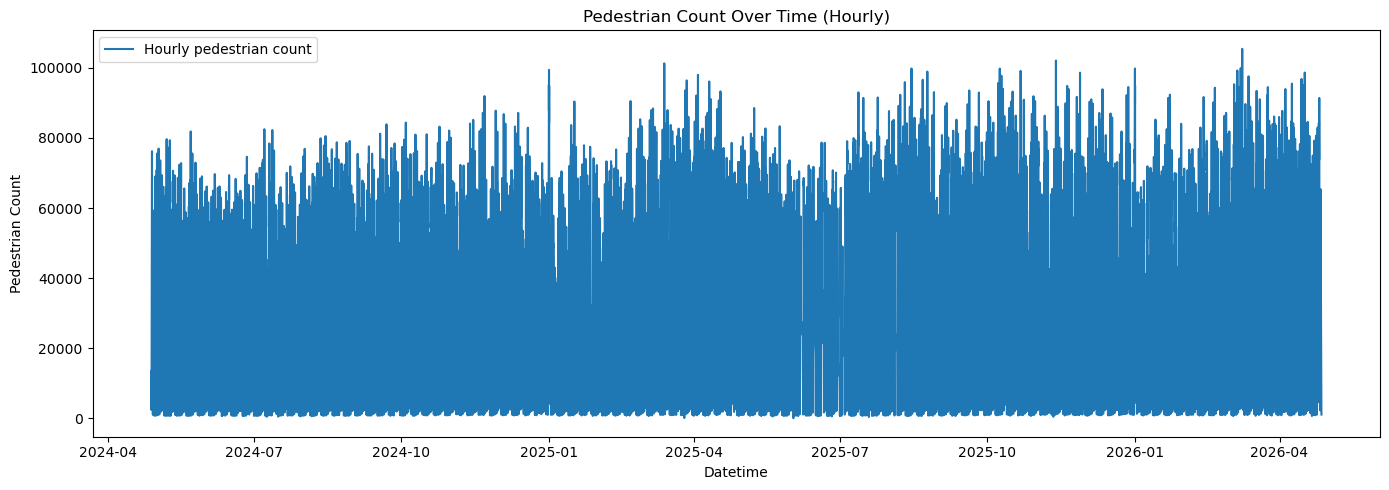

In [55]:
# Plot pedestrian counts over time.
plt.figure(figsize=(14, 5))
plt.plot(
    model_df["datetime_hour"],
    model_df["pedestriancount"],
    label="Hourly pedestrian count"
)

plt.title("Pedestrian Count Over Time (Hourly)")
plt.xlabel("Datetime")
plt.ylabel("Pedestrian Count")
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 Average Pedestrian Count By Day Of Week

**Justification**

The day-of-week summary was checked to see if there may also be other variables like work patterns, shopping activities, or weekend behaviours that might have influenced the pedestrian demand. Also checks whether the day of the week should be considered an important time-based feature for later modelling (35, 37).

**Output Explanation**

From the plot, it does seem like the weekdays tend to be relatively high along with Saturdays, whereas Mondays and Sundays tend to have low pedestrian demands. Monday might be low despite being a normal workday for the average Australians might be due to the influence of public holidays, and Sunday being low is due to most people not working on Sunday, since businesses would usually pay a high penalty rate. This further suggests that the CBD pedestrian pattern is linked to weekday economic and commuter activity, not just climate variables.

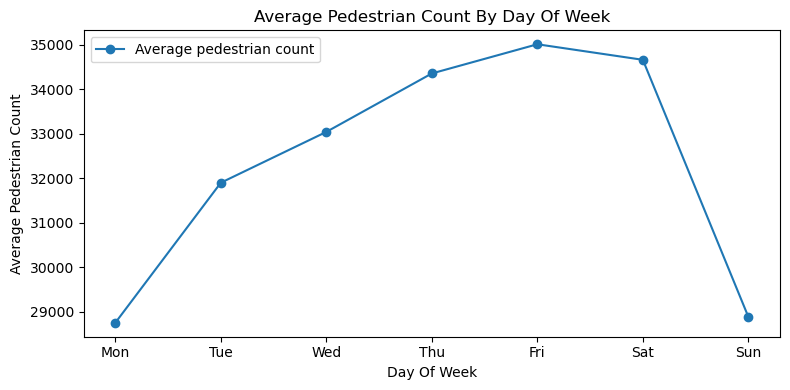

In [57]:
# Create a day-of-week column.
model_df["day_of_week"] = model_df[
    "datetime_hour"
].dt.dayofweek

# Group by day of week.
dow_pattern = model_df.groupby("day_of_week")[
    "pedestriancount"
].mean()

# Plot the day-of-week pattern.
plt.figure(figsize=(8, 4))
plt.plot(
    dow_pattern.index,
    dow_pattern.values,
    marker="o",
    label="Average pedestrian count"
)

plt.title("Average Pedestrian Count By Day Of Week")
plt.xlabel("Day Of Week")
plt.ylabel("Average Pedestrian Count")
plt.xticks(
    ticks=range(7),
    labels=[
        "Mon", "Tue", "Wed",
        "Thu", "Fri", "Sat", "Sun"
    ]
)
plt.legend()
plt.tight_layout()
plt.show()

### 6.3 Distributions Of Variables

**Justification**

Checking for distribution to see whether it's symmetric, skewed, or multi-modal. This is useful because skewed variables, extreme values, or unusual distributions can influence how the model learns from the data (38).

**Output Explanation**

- pedestriancount appears unimodal and right-skewed.
- airtemperature appears unimodal with a slight right skew.
- relativehumidity appears unimodal with a slight left skew.
- atmosphericpressure appears unimodal and slightly left-skewed.
- averagewindspeed appears unimodal and right-skewed.
- gustwindspeed appears unimodal and right-skewed.
- averagewinddirection appears roughly unimodal and mostly symmetric.
- pm25 appears unimodal and right-skewed.
- pm10 appears unimodal and right-skewed, similar to pm25.
- noise appears unimodal and fairly symmetric.

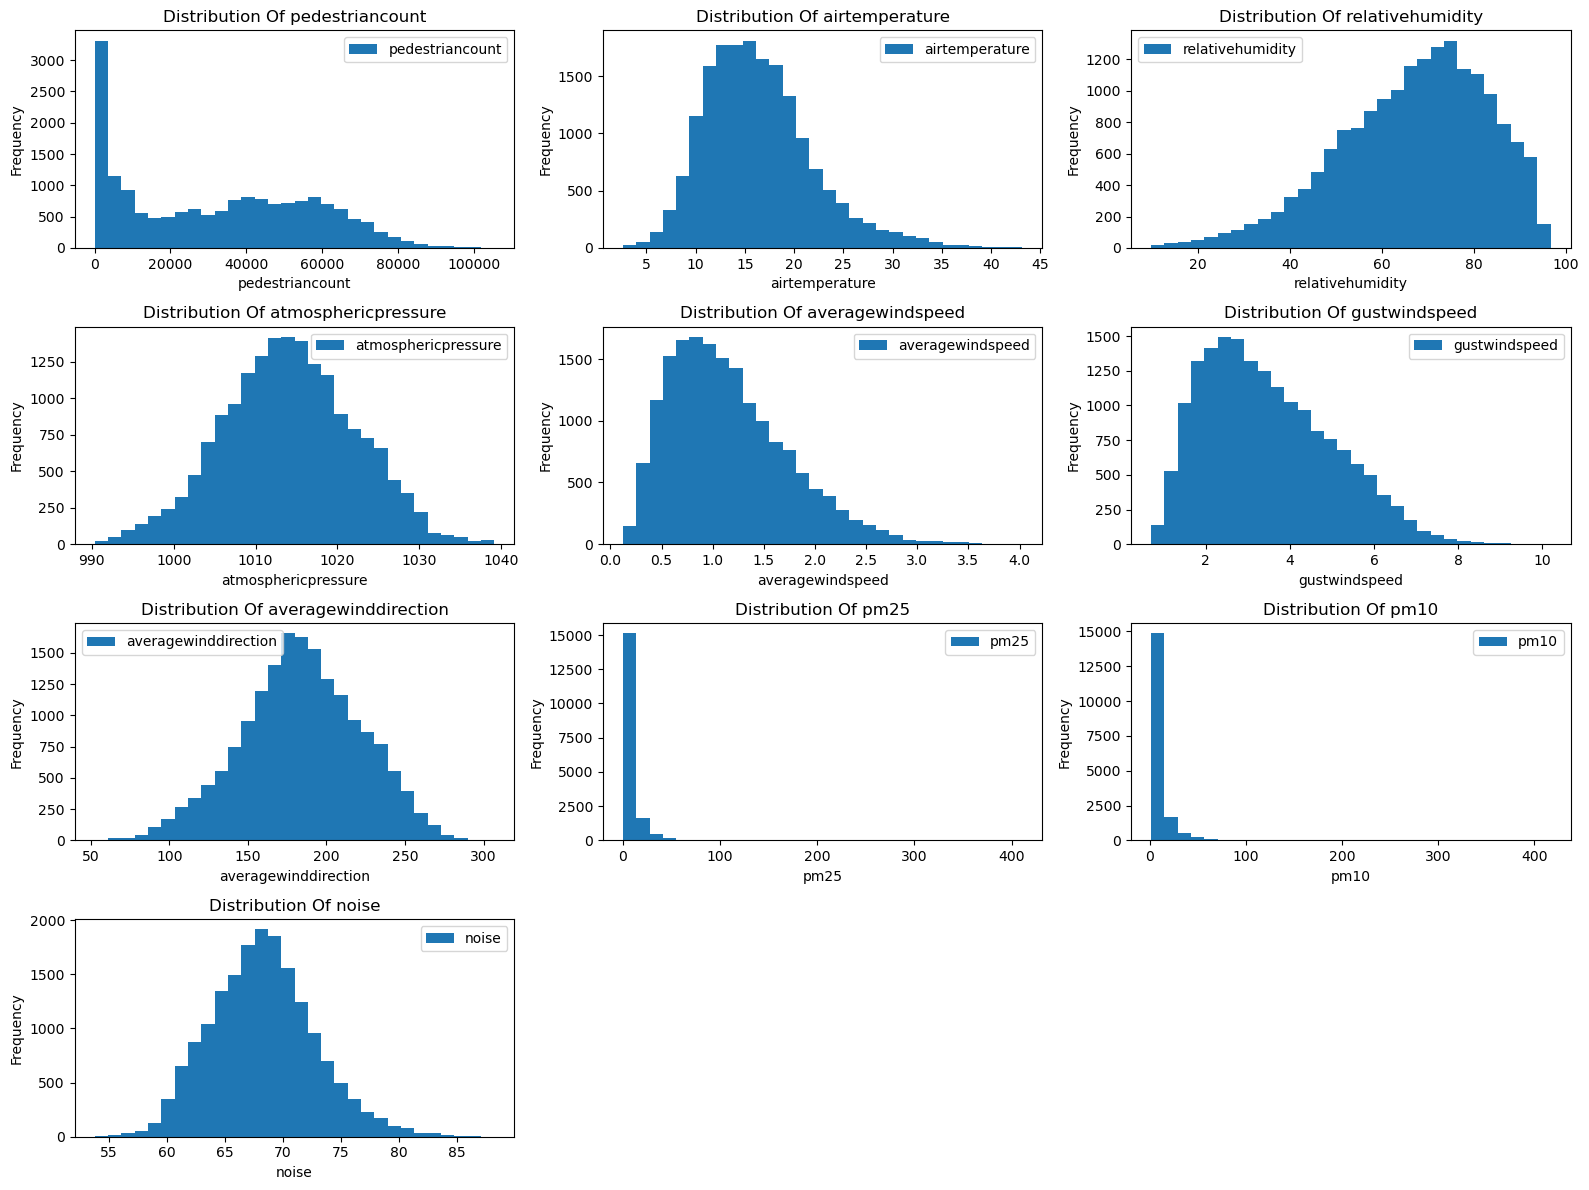

In [59]:
# Store numeric columns.
numeric_cols = model_df.select_dtypes(
    include=["int32", "int64", "float64"]
).columns.drop(
    ["day_of_week"],
    errors="ignore"
)

# Create subplot layout.
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 12)
)

axes = axes.flatten()

# Plot histogram for each numeric column.
for i, col in enumerate(numeric_cols):
    axes[i].hist(
        model_df[col],
        bins=30,
        label=col
    )
    axes[i].set_title(f"Distribution Of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

# Remove empty subplots.
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 6.4 Correlation Matrix

**Justification**

Checking the correlation matrix is a quick way to see which climate variables might have the strongest relationship with pedestrian demand, which does seem like they have some influence on the target variable from the results. This is mainly to show whether the relationship is positive or negative, even though correlation does not prove causation (39).

**Output Explanation**

- noise has the strongest positive correlation with pedestrian count, followed by gustwindspeed, airtemperature, averagewindspeed, and averagewinddirection. This suggests that pedestrian activity tends to increase when these variables increase.
- relativehumidity has the strongest negative correlation with pedestrian count, while pm10, pm25, and atmosphericpressure have weaker negative relationships. This suggests that pedestrian activity tends to decrease when these variables increase.

This suggests that climate variables do play a role in influencing the pedestrian demand, but there are other influences as well as discovered from previous plots. But the goal for this task is to understand how climate variables affect pedestrian demands.

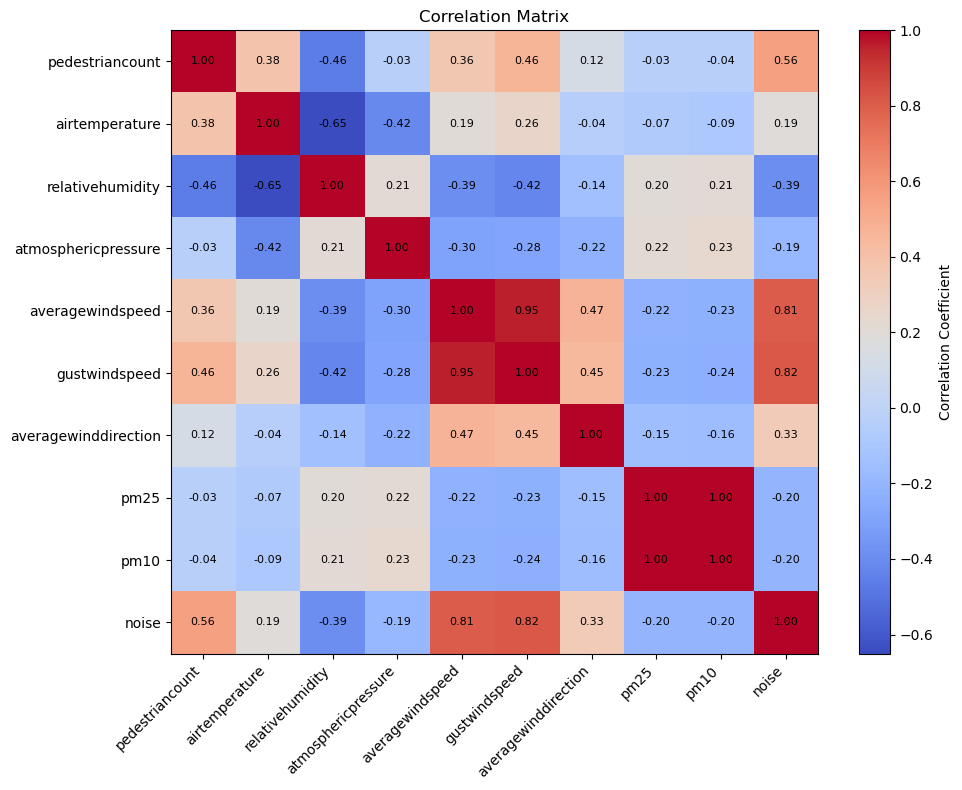

pedestriancount         1.000000
noise                   0.558378
gustwindspeed           0.463035
airtemperature          0.383669
averagewindspeed        0.361236
averagewinddirection    0.123501
atmosphericpressure    -0.031982
pm25                   -0.032611
pm10                   -0.035924
relativehumidity       -0.457393
Name: pedestriancount, dtype: float64


In [61]:
# Calculate the correlation matrix.
corr_matrix = model_df[numeric_cols].corr()

# Plot the correlation matrix.
plt.figure(figsize=(10, 8))
im = plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    aspect="auto"
)

cbar = plt.colorbar(im)
cbar.set_label("Correlation Coefficient")

plt.xticks(
    ticks=np.arange(len(corr_matrix.columns)),
    labels=corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(corr_matrix.columns)),
    labels=corr_matrix.columns
)

plt.title("Correlation Matrix")

# Add values inside each cell.
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

# Print the correlation values with pedestrian count.
print(corr_matrix["pedestriancount"].sort_values(ascending=False))

## 7. Time Series Analysis

This section is necessary as exploratory data analysis alone is not enough to check a time series dataset. Hence, time series analysis is necessary to help uncover more trends, seasonality, repeated lag dependence, and stationarity (36).

### 7.1 Pedestrian Count Over Time (24-Hour Rolling Mean)

**Justification**

The previous plot with the pedestrian count over time was noisy, so smoothing over 24 hours may help reveal more patterns of pedestrian activity without the hour-to-hour volatility (40).

**Output Explanation**

From the plot, it became much more obvious that the highest peaks were during New Year's, where pedestrian visit the Melbourne CBD to see the fireworks, and confirms what has been previously discussed. There does seem to be a slightly increasing trend, which suggests that the influence of COVID-19 is still recovering.

In [64]:
# Create the hourly target series.
ts = model_df.set_index("datetime_hour")[
    "pedestriancount"
].sort_index()

# Check the first few rows.
print(ts.head())

datetime_hour
2024-04-28 00:00:00    13537
2024-04-28 01:00:00     9577
2024-04-28 02:00:00     6819
2024-04-28 03:00:00     5084
2024-04-28 04:00:00     2628
Name: pedestriancount, dtype: int32


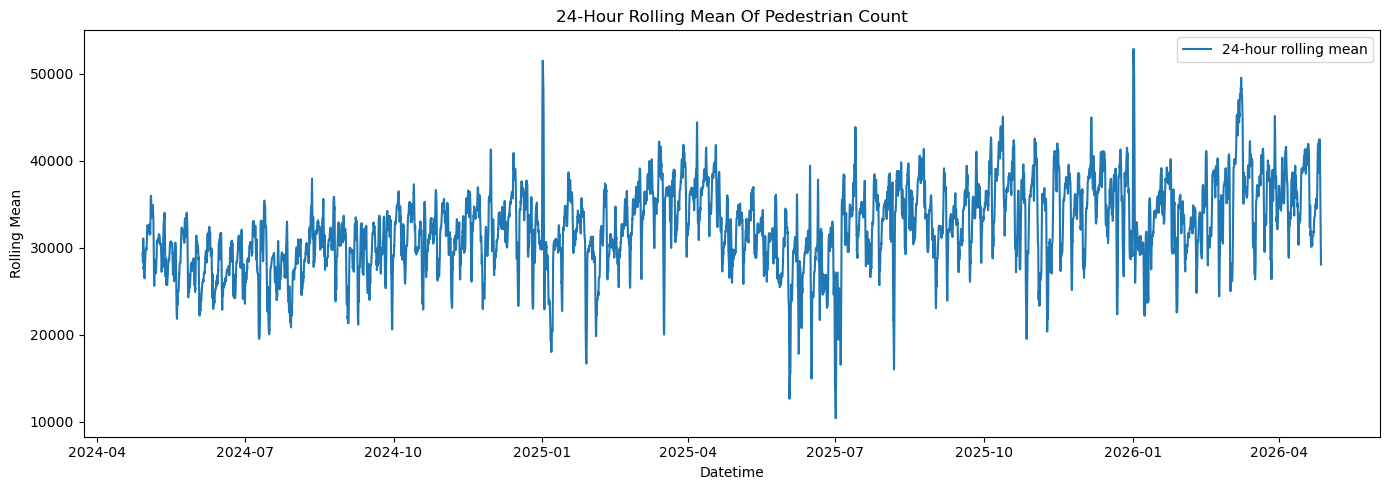

In [65]:
# Calculate the 24-hour rolling mean.
rolling_mean_24 = ts.rolling(24).mean()

# Plot the rolling mean only.
plt.figure(figsize=(14, 5))
plt.plot(
    rolling_mean_24,
    label="24-hour rolling mean"
)

plt.title("24-Hour Rolling Mean Of Pedestrian Count")
plt.xlabel("Datetime")
plt.ylabel("Rolling Mean")
plt.legend()
plt.tight_layout()
plt.show()

### 7.2 Seasonal Pattern (24-Hour Cycle)

**Justification**

Seasonal decomposition is necessary because hourly pedestrian demand is expected to have a strong daily cycle, so checking the seasonal component can help check how the typical hour of the day affects pedestrian activity. Since people usually move through the city at different levels during the morning, workday, evening, and late night, this step helps show whether the hour of the day is a factor in pedestrian demand (41).

**Output Explanation**

From the plot, it is clear that the seasonal effect is strongly negative at night and becomes strongly positive during the workday, especially the peak at 5 PM, when most people finish work and are looking to go home. The lowest tends to be around 3 AM, which is expected, since people tend to party late until 12 PM before heading home, and the other reason is that the city's pedestrian activities are very limited at that time. This plot further confirms that hour-of-day is a major driver of pedestrian demand, and there may be other variables influencing pedestrian demand.


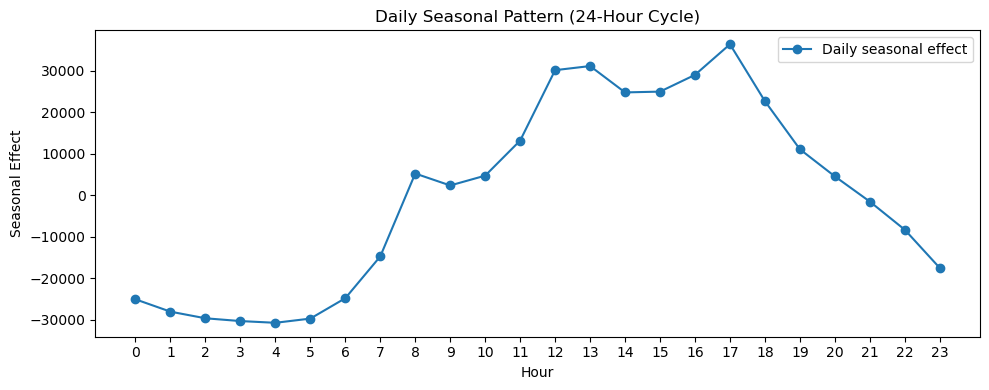

In [67]:
# Decompose the series using a 24-hour period.
decomp_24 = seasonal_decompose(
    ts,
    model="additive",
    period=24
)

# Store one seasonal cycle and align it to the actual hours.
seasonal_24 = pd.Series(
    decomp_24.seasonal[:24].values,
    index=ts.index[:24].hour
)

# Sort by actual hour.
seasonal_24 = seasonal_24.sort_index()

# Plot the corrected daily seasonal pattern.
plt.figure(figsize=(10, 4))
plt.plot(
    seasonal_24.index,
    seasonal_24.values,
    marker="o",
    label="Daily seasonal effect"
)

plt.title("Daily Seasonal Pattern (24-Hour Cycle)")
plt.xlabel("Hour")
plt.ylabel("Seasonal Effect")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

### 7.3 Autocorrelation Of Pedestrian Count

**Justification**

Checking for autocorrelation is important because it shows whether the current pedestrian demand depends on previous hours, and if strong dependence exists, then lag features will be very useful for forecasting (42).

**Output Explanation**

From the plot, there appears to be a very strong repeating pattern at a regular interval, especially around daily cycles. This repeated structure applies not only on the daily level, but also appears to be on the weekly level as well, meaning daily and weekly lag features will be useful for predictions.

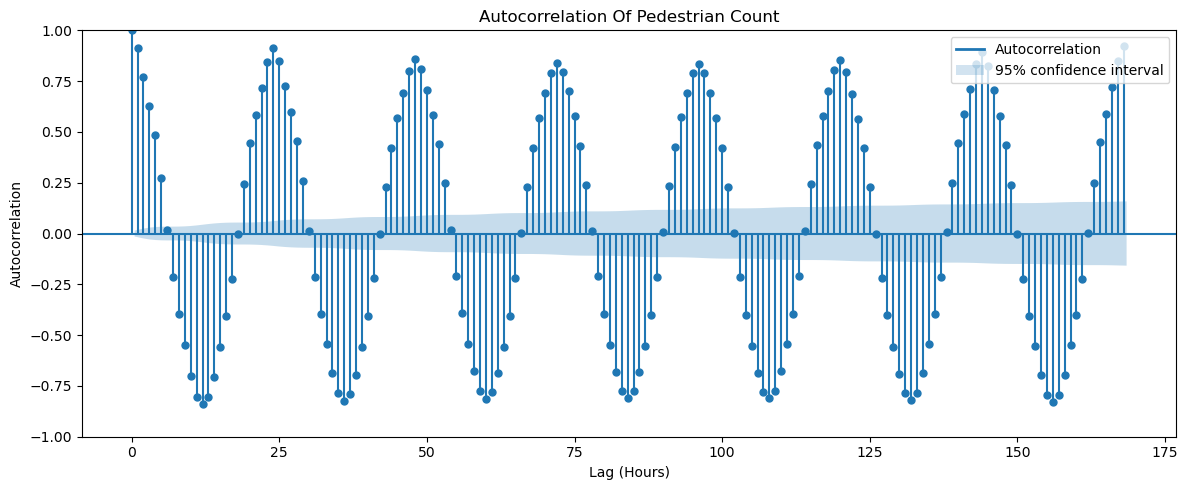

In [69]:
# Plot autocorrelation for one week of hourly lags.
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(ts, lags=168, ax=ax)

ax.set_title("Autocorrelation Of Pedestrian Count")
ax.set_xlabel("Lag (Hours)")
ax.set_ylabel("Autocorrelation")

# Add legend handles.
legend_handles = [
    Line2D([0], [0], color="C0", lw=2, label="Autocorrelation"),
    Patch(alpha=0.2, label="95% confidence interval")
]

ax.legend(handles=legend_handles, loc="upper right")
plt.tight_layout()
plt.show()

### 7.4 Augmented Dickey-Fuller Test

**Justification**

The Augmented Dickey-Fuller Test checks whether the time series is statistically stationary in the unit-root sense, and while not necessary for deep learning modelling, it does provide some more understanding of the patterns underlying the merged dataset (43).

**Output Explanation**

The result was that the p-value is extremely small and the test statistic is far below the critical values, hence, the null hypothesis of a unit root is rejected. This means that the time series dataset is statistically stationary enough to exhibit a learnable structure rather than behaving like a random walk, which basically means that it's not necessarily a random coin toss in layman's terms.

In [71]:
# Run the Augmented Dickey-Fuller test.
adf_result = adfuller(ts)

# Print the results.
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -12.32948806412054
p-value: 6.475296799015953e-23
Critical Values:
1%: -3.4307246927489876
5%: -2.861705599696249
10%: -2.5668581444244114


## 8. Feature Engineering

The feature engineering section is necessary because the current variables in the merged datasets may not necessarily be enough for a strong forecasting model, so doing feature engineering will create more useful variables that help capture other aspects of the datasets, like cyclical structures, recent history, and short-term trends (44, 45).

### 8.1 Creating Time Features

**Justification**

Creating more calendar-based features is necessary because pedestrian activity depends on when that observation happened, as shown in previous plots. Hence, hours, day of week, month, and weekend status are all useful predictors. This step ensures the datetime_hour column is converted into its individual components (45).

**Output Explanation**

The output shows that new time-based columns were added to the dataset. These include hour, day_of_week, month, and is_weekend.

In [74]:
# Create a copy for feature engineering.
features_df = model_df.copy()

# Extract calendar features.
features_df["hour"] = features_df["datetime_hour"].dt.hour
features_df["day_of_week"] = (
    features_df["datetime_hour"].dt.dayofweek
)
features_df["month"] = features_df["datetime_hour"].dt.month
features_df["is_weekend"] = (
    features_df["day_of_week"] >= 5
).astype(int)

# Check the result.
print(
    features_df[
        [
            "datetime_hour", "hour", "day_of_week", "month", 
            "is_weekend"
        ]
    ].head()
)

        datetime_hour  hour  day_of_week  month  is_weekend
0 2024-04-28 00:00:00     0            6      4           1
1 2024-04-28 01:00:00     1            6      4           1
2 2024-04-28 02:00:00     2            6      4           1
3 2024-04-28 03:00:00     3            6      4           1
4 2024-04-28 04:00:00     4            6      4           1


### 8.2 Creating Cyclical Time Features

**Justification**

Cyclical encoding is necessary since time variables are cyclical and not linear, like a clock. If we're talking just normal values like 0 and 23, these two values are quite far apart, but it's not, since it's time and there's only 1 hour difference. Using sine and cosine preserves that circular structure. This step ensures that the time variables are cyclical and prevents the models from learning misleading distances between values at the edge of a cycle (46).

**Output Explanation**

The output shows that new cyclical time features were created, including hour_sin, hour_cos, dow_sin, dow_cos, month_sin, and month_cos.

In [76]:
# Hour and day of week are cyclical, not linear.
# Create cyclical hour features.
features_df["hour_sin"] = np.sin(
    2 * np.pi * features_df["hour"] / 24
)
features_df["hour_cos"] = np.cos(
    2 * np.pi * features_df["hour"] / 24
)

# Create cyclical day-of-week features.
features_df["dow_sin"] = np.sin(
    2 * np.pi * features_df["day_of_week"] / 7
)
features_df["dow_cos"] = np.cos(
    2 * np.pi * features_df["day_of_week"] / 7
)

# Convert cyclical month features.
features_df["month_sin"] = np.sin(
    2 * np.pi * features_df["month"] / 12
)
features_df["month_cos"] = np.cos(
    2 * np.pi * features_df["month"] / 12
)

# Check the result.
print(
    features_df[
        [
            "datetime_hour", "hour_sin", "hour_cos",
            "dow_sin", "dow_cos", "month_sin", 
            "month_cos"
        ]
    ].head()
)

        datetime_hour  hour_sin  hour_cos   dow_sin  dow_cos  month_sin  \
0 2024-04-28 00:00:00  0.000000  1.000000 -0.781831  0.62349   0.866025   
1 2024-04-28 01:00:00  0.258819  0.965926 -0.781831  0.62349   0.866025   
2 2024-04-28 02:00:00  0.500000  0.866025 -0.781831  0.62349   0.866025   
3 2024-04-28 03:00:00  0.707107  0.707107 -0.781831  0.62349   0.866025   
4 2024-04-28 04:00:00  0.866025  0.500000 -0.781831  0.62349   0.866025   

   month_cos  
0       -0.5  
1       -0.5  
2       -0.5  
3       -0.5  
4       -0.5  


### 8.3 Creating Cyclical Wind Direction Features

**Justification**

Wind direction is also circular, being 360 degrees, meaning 0 and 359 degrees are almost the same direction. So wind direction must also be converted to cyclical for a continuous form, and ensure consistency with treatments of cyclical variables like time (46).

**Output Explanation**

The output shows that two new features were created, wind_dir_sin and wind_dir_cos.

In [78]:
# Convert wind direction into cyclical form.
features_df["wind_dir_sin"] = np.sin(
    2 * np.pi * features_df["averagewinddirection"] / 360
)
features_df["wind_dir_cos"] = np.cos(
    2 * np.pi * features_df["averagewinddirection"] / 360
)

# Check the result.
print(
    features_df[
        [
            "averagewinddirection",
            "wind_dir_sin",
            "wind_dir_cos"
        ]
    ].head()
)

   averagewinddirection  wind_dir_sin  wind_dir_cos
0            149.750000      0.503774     -0.863836
1            159.892857      0.343777     -0.939051
2            192.074074     -0.209176     -0.977878
3            144.250000      0.584250     -0.811574
4            159.964286      0.342606     -0.939479


### 8.4 Creating Lag Features

**Justification**

Lag features are important, as indicated by the autocorrelation plot, since pedestrian demand is highly dependent on recent history based on the autocorrelation plot (47, 48).

**Output Explanation**

The features lag_1, lag_24, and lag_168 capture the previous hour, previous day, and previous week at the same hour. This does create missing values since there wasn't recent information to populate the lag columns for specific rows, which will be dealt with. Like the very first row having a missing value for lag_1, because there wasn't a previous row to populate that value.

In [80]:
# Create lagged pedestrian count features.
features_df["lag_1"] = (
    features_df["pedestriancount"].shift(1)
)

features_df["lag_24"] = (
    features_df["pedestriancount"].shift(24)
)

features_df["lag_168"] = (
    features_df["pedestriancount"].shift(168)
)

# Check the result.
print(
    features_df[
        [
            "lag_1", "lag_24", "lag_168"
        ]
    ].head(25)
)

      lag_1   lag_24  lag_168
0       NaN      NaN      NaN
1   13537.0      NaN      NaN
2    9577.0      NaN      NaN
3    6819.0      NaN      NaN
4    5084.0      NaN      NaN
5    2628.0      NaN      NaN
6    2462.0      NaN      NaN
7    3516.0      NaN      NaN
8    6407.0      NaN      NaN
9   11321.0      NaN      NaN
10  25496.0      NaN      NaN
11  42386.0      NaN      NaN
12  49658.0      NaN      NaN
13  60225.0      NaN      NaN
14  67464.0      NaN      NaN
15  76217.0      NaN      NaN
16  63682.0      NaN      NaN
17  54207.0      NaN      NaN
18  50920.0      NaN      NaN
19  45636.0      NaN      NaN
20  34508.0      NaN      NaN
21  29202.0      NaN      NaN
22  22597.0      NaN      NaN
23  15210.0      NaN      NaN
24   8389.0  13537.0      NaN


### 8.5 Creating Rolling Features

**Justification**

Rolling features summarise recent pedestrian counts rather than relying on a single observation for a datapoint, allowing the model to capture the short-term trend and help smooth the short-term noise (47).

**Output Explanation**

Some new predictors were added, like rolling_mean_24, which summarises the previous 24 hours, while rolling_mean_168 summarises the previous week. And as expected, similar to lag features but not the same, the first rows are missing values since the rolling window cannot be calculated until enough history exists. 

In [82]:
# Create rolling mean features from past counts.
features_df["rolling_mean_24"] = (
    features_df["pedestriancount"]
    .shift(1)
    .rolling(24)
    .mean()
)

features_df["rolling_mean_168"] = (
    features_df["pedestriancount"]
    .shift(1)
    .rolling(168)
    .mean()
)

# Check the result.
print(
    features_df[
        [
            "rolling_mean_24", "rolling_mean_168"
        ]
    ].head(25)
)

    rolling_mean_24  rolling_mean_168
0               NaN               NaN
1               NaN               NaN
2               NaN               NaN
3               NaN               NaN
4               NaN               NaN
5               NaN               NaN
6               NaN               NaN
7               NaN               NaN
8               NaN               NaN
9               NaN               NaN
10              NaN               NaN
11              NaN               NaN
12              NaN               NaN
13              NaN               NaN
14              NaN               NaN
15              NaN               NaN
16              NaN               NaN
17              NaN               NaN
18              NaN               NaN
19              NaN               NaN
20              NaN               NaN
21              NaN               NaN
22              NaN               NaN
23              NaN               NaN
24          29464.5               NaN


### 8.6 Removing NA Rows

**Justification**

This step removes the rows with missing values created from the lag and rolling features at the beginning of the ordered merged dataset, since they cannot be used as they are incomplete predictor information. By removing these rows, the dataset lost a part of the early period as a trade-off in the pipeline, which is reasonable considering the dataset is being updated in real-time, so there will be more data points to use in the future, hence, negligible (48).

**Output Explanation**

The output shows that all rows with missing values were removed, and the dataset was reset into a clean index.

In [84]:
# Remove rows with NAs.
features_df = features_df.dropna().reset_index(drop=True)

# Check the result.
print(features_df.info())
print(features_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17332 entries, 0 to 17331
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime_hour         17332 non-null  datetime64[ns]
 1   pedestriancount       17332 non-null  int32         
 2   airtemperature        17332 non-null  float64       
 3   relativehumidity      17332 non-null  float64       
 4   atmosphericpressure   17332 non-null  float64       
 5   averagewindspeed      17332 non-null  float64       
 6   gustwindspeed         17332 non-null  float64       
 7   averagewinddirection  17332 non-null  float64       
 8   pm25                  17332 non-null  float64       
 9   pm10                  17332 non-null  float64       
 10  noise                 17332 non-null  float64       
 11  day_of_week           17332 non-null  int32         
 12  hour                  17332 non-null  int32         
 13  month           

### 8.7 Removing Unnecessary Features

**Justification**

Since the cyclical variables were created, the original raw cyclical variables have become redundant. So removing these variables helps reduce feature duplication and makes the modelling easier and cleaner (23, 24).

**Output Explanation**

The averagewinddirection, hour, day_of_week, and month columns are dropped. Resulting in 24 columns, including the target pedestrian count, selected climate variables, is_weekend, cyclical encodings, lag features, and rolling means. The datetime_hour is temporarily kept, but will be removed later on as well.

In [86]:
# Drop raw columns that now have cyclical replacements.
features_df = features_df.drop(
    columns=[
        "averagewinddirection",
        "hour",
        "day_of_week",
        "month",
    ]
)

# Reorder the columns into a cleaner structure.
features_df = features_df[
    [
        "datetime_hour",
        "pedestriancount",
        "airtemperature",
        "relativehumidity",
        "atmosphericpressure",
        "averagewindspeed",
        "gustwindspeed",
        "pm25",
        "pm10",
        "noise",
        "is_weekend",
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
        "month_sin",
        "month_cos",
        "wind_dir_sin",
        "wind_dir_cos",
        "lag_1",
        "lag_24",
        "lag_168",
        "rolling_mean_24",
        "rolling_mean_168",
    ]
]

# Check the result.
print(features_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17332 entries, 0 to 17331
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   datetime_hour        17332 non-null  datetime64[ns]
 1   pedestriancount      17332 non-null  int32         
 2   airtemperature       17332 non-null  float64       
 3   relativehumidity     17332 non-null  float64       
 4   atmosphericpressure  17332 non-null  float64       
 5   averagewindspeed     17332 non-null  float64       
 6   gustwindspeed        17332 non-null  float64       
 7   pm25                 17332 non-null  float64       
 8   pm10                 17332 non-null  float64       
 9   noise                17332 non-null  float64       
 10  is_weekend           17332 non-null  int32         
 11  hour_sin             17332 non-null  float64       
 12  hour_cos             17332 non-null  float64       
 13  dow_sin              17332 non-

## 9. Preparing Train/Val/Test Splits

Preparing the splits is necessary for training a forecasting model, so that the future periods are evaluated, and not on randomly selected time periods. Hence, splitting the dataset based on time is important so that the model being trained on the past can predict the future, like in real-world scenarios (49).


### 9.1 Splitting The Data By Time

**Justification**

Chronological splitting in time-series forecasting is to prevent leaking future information into the training process. For example is if random splitting were to be used, then a model can be trained on data points in 2026, but is tested on a time period in 2025. Hence, the validation and test set must be later, and the training set must be the past, as shown here (49).

The split for training, validation and testing is 80:10:10 to ensure that there are enough data points used for training, with enough data points to perform validation and testing. Deep learning tends to require a large number of data points, so using this split ratio prevents underfitting (50).

**Output Explanation**

The output confirms that the data was split chronologically, with the training data coming first, followed by validation and testing data.

In [89]:
# Set the split sizes (80:10:10).
train_size = int(len(features_df) * 0.8)
val_size = int(len(features_df) * 0.1)

# Split the data in chronological order.
train_df = features_df.iloc[:train_size].copy()
val_df = features_df.iloc[
    train_size:train_size + val_size
].copy()
test_df = features_df.iloc[
    train_size + val_size:
].copy()

# Check the shapes.
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(13865, 24)
(1733, 24)
(1734, 24)


In [90]:
# Checking The Split Ranges.
print("Train range:")
print(train_df["datetime_hour"].min())
print(train_df["datetime_hour"].max())

print("\nValidation range:")
print(val_df["datetime_hour"].min())
print(val_df["datetime_hour"].max())

print("\nTest range:")
print(test_df["datetime_hour"].min())
print(test_df["datetime_hour"].max())

Train range:
2024-05-05 00:00:00
2025-12-03 16:00:00

Validation range:
2025-12-03 17:00:00
2026-02-13 21:00:00

Test range:
2026-02-13 22:00:00
2026-04-27 03:00:00


### 9.2 Separating Features And Target

**Justification**

This step is necessary to separate the predictor inputs X and the output target y. This is necessary because the model needs to know which columns are used as inputs and which column it needs to predict (51).

**Output Explanation**

The target is set to pedestriancount, which is the variable the model is trying to predict. The datetime column is excluded from the features since the chronological splitting is completed, so this leaves 22 predictor columns for each split, as shown in the shapes output.

In [92]:
# Store the target column name.
target_col = "pedestriancount"

# Store the feature column names.
feature_cols = [
    col for col in features_df.columns
    if col not in ["datetime_hour", target_col]
]

# Create X and y for each split.
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

# Check the shapes.
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(13865, 22) (13865,)
(1733, 22) (1733,)
(1734, 22) (1734,)


### 9.3 Scaling The Features

**Justification**

Scaling the features is necessary because the predictor variables are measured on different scales. For example, temperature, humidity, air pressure, wind speed, pollution values, and lagged pedestrian counts all have different ranges. Hence, needs to be standardised so that the variables are unitless, allowing the variables to be able to directly compared (52).

Standardisation basically sets the predictors to have a mean of 0 and a standard deviation of 1. This allows faster convergence when all the input features are on the same scale, preventing feature dominance due to differences in magnitudes, and is generally more stable (52).

**Output Explanation**

The output shows that the training, validation, and test feature sets were successfully scaled using StandardScaler.

In [94]:
# Create the feature scaler.
x_scaler = StandardScaler()

# Fit on training features only.
X_train_scaled = x_scaler.fit_transform(X_train)

# Transform validation and test features.
X_val_scaled = x_scaler.transform(X_val)
X_test_scaled = x_scaler.transform(X_test)

# Create the target scaler.
y_scaler = StandardScaler()

# Fit on training target only.
y_train_scaled = y_scaler.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).flatten()

# Transform validation and test targets.
y_val_scaled = y_scaler.transform(
    y_val.to_numpy().reshape(-1, 1)
).flatten()

y_test_scaled = y_scaler.transform(
    y_test.to_numpy().reshape(-1, 1)
).flatten()

# Check the shapes.
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)
print(y_train_scaled.shape)
print(y_val_scaled.shape)
print(y_test_scaled.shape)

(13865, 22)
(1733, 22)
(1734, 22)
(13865,)
(1733,)
(1734,)


### 9.4 Creating LSTM Sequences

**Justification**

Creating LSTM sequences is necessary because an LSTM model needs data in a sequential format, rather than as separate individual rows. Since this project uses hourly time-series data, the model should look at a window of past observations before predicting the current pedestrian count. A sequence length of 24 hours is used so the model can learn from the previous full day of pedestrian, climate, and time-based patterns (53).

**Output Explanation**

The output shows that the scaled training, validation, and test data were converted into 3D LSTM input sequences.

In [96]:
# Set the sequence length.
SEQ_LEN = 24

# Build rolling sequences.
def make_sequences(X, y, seq_len=24):
    X_seq = []
    y_seq = []

    for i in range(seq_len - 1, len(X)):
        X_seq.append(X[i - seq_len + 1:i + 1])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

# Create scaled sequences.
X_train_seq, y_train_seq = make_sequences(
    X_train_scaled,
    y_train_scaled,
    SEQ_LEN
)

X_val_seq, y_val_seq = make_sequences(
    X_val_scaled,
    y_val_scaled,
    SEQ_LEN
)

X_test_seq, y_test_seq = make_sequences(
    X_test_scaled,
    y_test_scaled,
    SEQ_LEN
)

# Create raw target sequences for evaluation.
_, y_val_actual = make_sequences(
    X_val_scaled,
    y_val.to_numpy(),
    SEQ_LEN
)

_, y_test_actual = make_sequences(
    X_test_scaled,
    y_test.to_numpy(),
    SEQ_LEN
)

# Check the shapes.
print(X_train_seq.shape, y_train_seq.shape)
print(X_val_seq.shape, y_val_seq.shape)
print(X_test_seq.shape, y_test_seq.shape)

(13842, 24, 22) (13842,)
(1710, 24, 22) (1710,)
(1711, 24, 22) (1711,)


## 10. Baseline LSTM Model

A baseline LSTM model will be built with randomly specified settings to set the baseline model performance to compare with later models using hyperparameter tuning. Basically helps to decide whether later optimisation improves the model's performance (54, 55).

### 10.1 Model Building

**Justification**

The baseline model uses the Adam optimiser because it adjusts the learning rate during training, which makes it efficient and stable for deep learning tasks (56). The MSE loss function is used because this is a regression problem where the model is predicting a numeric pedestrian count (57). Early stopping is also included to prevent unnecessary training once the validation loss stops improving, since performance may worsen once it plateaus due to overfitting, resulting in worse performance on validation sets (58).

**Output Explanation**

The training loss and validation loss both decrease over time, which means that the model is learning patterns from the training data (59). It does reach a plateau at a certain point, and the validation loss starts going up a bit. Hence, the early stopping happened, putting a stop to the training process and restoring the lowest validation loss model weights (58, 59).

In [99]:
# Build a baseline LSTM model.
def build_lstm(units=16, dropout=0.1, lr=0.001):
    model = Sequential([
        Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
        LSTM(units),
        Dropout(dropout),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse"
    )

    return model

# Create the model with baseline settings.
baseline_model = build_lstm(
    units=32,
    dropout=0.0,
    lr=0.001
)

# Stop early if validation stops improving.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train the baseline model.
baseline_history = baseline_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.1367 - val_loss: 0.1070
Epoch 2/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0577 - val_loss: 0.0692
Epoch 3/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0394 - val_loss: 0.0549
Epoch 4/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0335 - val_loss: 0.0497
Epoch 5/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0309 - val_loss: 0.0470
Epoch 6/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0292 - val_loss: 0.0452
Epoch 7/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0280 - val_loss: 0.0438
Epoch 8/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0269 - val_loss: 0.0427
Epoch 9/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0260 - val_loss: 0.0418
Epoch 10/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0252 - val_loss: 0.0409
Epoch 11/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0244 - val_loss: 0.0402
Epoch 12/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

### 10.2 Baseline Loss Plot

**Justification**

Plotting the baseline LSTM model is necessary to see how the model was performing throughout the training process. The training loss curve shows how well it's learning from the training data, and the validation loss curve shows how the model trained on the training data performs on the validation data that it hasn't seen before (59).

**Output Explanation**

The output shows the training loss and validation loss across each epoch for the baseline LSTM model, with the training loss still going down, but early stopping happened since the validation loss was starting to go back up, meaning overfitting was starting to happen (58, 59).

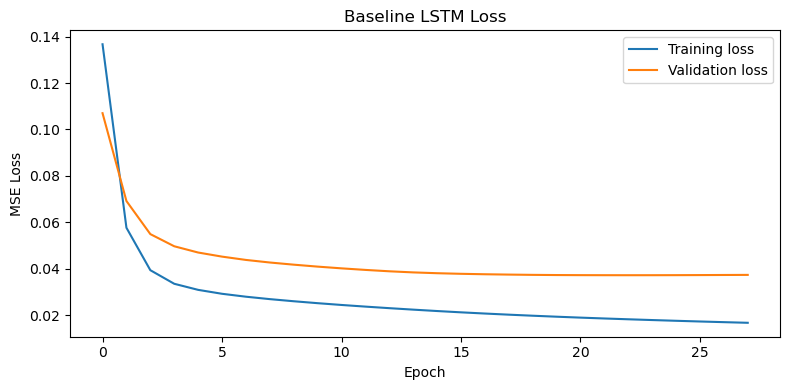

In [101]:
# Plot the training history.
plt.figure(figsize=(8, 4))
plt.plot(
    baseline_history.history["loss"],
    label="Training loss"
)
plt.plot(
    baseline_history.history["val_loss"],
    label="Validation loss"
)
plt.title("Baseline LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Hyperparameter Tuning LSTM Model

Hyperparameter tuning is necessary because the baseline LSTM model may not use the best settings for this dataset. Different choices, such as the number of LSTM units, dropout rate, learning rate, and batch size, can affect how well the model learns from the time-series data (60, 61, 62, 63). This will ensure the evaluation metrics for the model's performance will be higher, avoiding overfitting/underfitting, and allowing faster convergence (60, 61, 62).

### 11.1 Model Building With Hyperparameter Comparisons

**Justification**

A small search space was used to compare multiple combinations, just to see what works best without using up too much computational power and time (60). The tuning grid includes different numbers of LSTM units, dropout rates, learning rates, and batch sizes. These hyperparameters were selected because more LSTM units can help the model learn more complex time-series patterns, dropout can reduce overfitting by randomly ignoring some neurons during training, the learning rate controls how quickly the model updates during training, and batch size affects training speed and model stability (60, 61, 62, 63).

**Output Explanation**

Multiple different combinations of hyperparameters were used to compare validation RMSE performance, which was stored, then sorted to determine the best performing settings with the lowest RMSE. Overall, the tuning result shows that adding dropout and increasing the LSTM units improved performance compared to the baseline settings. This tuned model is then saved for final comparison against the baseline model.

In [104]:
# Store a small tuning grid.
search_space = [
    {"units": 16, "dropout": 0.0, "lr": 0.001, "batch_size": 32},
    {"units": 32, "dropout": 0.0, "lr": 0.001, "batch_size": 32},
    {"units": 48, "dropout": 0.0, "lr": 0.001, "batch_size": 32},
    {"units": 64, "dropout": 0.0, "lr": 0.001, "batch_size": 32},
    {"units": 32, "dropout": 0.1, "lr": 0.001, "batch_size": 32},
    {"units": 48, "dropout": 0.1, "lr": 0.001, "batch_size": 32},
    {"units": 64, "dropout": 0.1, "lr": 0.0005, "batch_size": 32},
    {"units": 32, "dropout": 0.0, "lr": 0.0005, "batch_size": 32},
    {"units": 48, "dropout": 0.0, "lr": 0.0005, "batch_size": 32},
    {"units": 32, "dropout": 0.0, "lr": 0.001, "batch_size": 64},
]

# Store tuning results.
tuning_results = []
best_val_rmse = np.inf
best_params = None
tuned_model = None

# Try each setting.
for params in search_space:
    # Build the model.
    model = build_lstm(
        units=params["units"],
        dropout=params["dropout"],
        lr=params["lr"]
    )

    # Create a fresh early stopping callback.
    loop_early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    # Train the model.
    model.fit(
        X_train_seq,
        y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=50,
        batch_size=params["batch_size"],
        callbacks=[loop_early_stop],
        verbose=0
    )

    # Predict validation targets in scaled form.
    val_pred_scaled = model.predict(
        X_val_seq,
        verbose=0
    ).flatten()

    # Convert predictions back to original scale.
    val_pred = y_scaler.inverse_transform(
        val_pred_scaled.reshape(-1, 1)
    ).flatten()

    # Calculate validation RMSE.
    val_rmse = np.sqrt(
        mean_squared_error(y_val_actual, val_pred)
    )

    # Save the tuning result.
    tuning_results.append({
        "units": params["units"],
        "dropout": params["dropout"],
        "lr": params["lr"],
        "batch_size": params["batch_size"],
        "val_rmse": val_rmse,
    })

    # Keep the best model.
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_params = params
        tuned_model = model

# Show tuning results.
tuning_results_df = pd.DataFrame(tuning_results)
print(tuning_results_df.sort_values("val_rmse"))
print("\nBest parameters:")
print(best_params)

   units  dropout      lr  batch_size     val_rmse
4     32      0.1  0.0010          32  4329.624501
5     48      0.1  0.0010          32  4424.317779
6     64      0.1  0.0005          32  4435.875903
2     48      0.0  0.0010          32  4608.919555
1     32      0.0  0.0010          32  4661.006242
3     64      0.0  0.0010          32  4720.909591
7     32      0.0  0.0005          32  4848.243325
9     32      0.0  0.0010          64  4865.526417
0     16      0.0  0.0010          32  4964.180469
8     48      0.0  0.0005          32  4969.545054

Best parameters:
{'units': 32, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32}


## 12. Evaluating Model Performance

Evaluating a model's performance is important to see how well the model might work in the real-world. Hence, having some evaluation metrics ensures that this process is objective and comparable (65). Metrics such as MAE, RMSE, and R-squared help show how close the predictions are to the actual pedestrian counts and how well the model explains the overall variation in the target variable (64, 65, 66, 67).

### 12.1 Baseline Vs Best Hyperparameter Tuning Model

**Justification**

The evaluation uses MAE, RMSE, and R-squared because they are suitable metrics for a regression forecasting task (65). MAE measures the average absolute prediction error, so it shows how far the predicted pedestrian counts are from the actual values on average, so a lower MAE is better (66). RMSE also measures prediction error, but it gives larger errors more weight. This is useful because big mistakes in pedestrian demand forecasting are more important to detect, so a lower RMSE is better (64). R-squared measures how much of the variation in pedestrian count is explained by the model, this helps show the overall fit of the model, so a higher R-squared is better (67).

**Output Explanation**

The tuned model has a lower MAE than the baseline model, has a lower RMSE, and a higher R-squared. This shows that the tuned LSTM performs better than the baseline LSTM on the test dataset.

In [107]:
# Create a helper for model evaluation.
def evaluate_model(model, X_seq, y_true, model_name):
    # Predict scaled values.
    pred_scaled = model.predict(
        X_seq,
        verbose=0
    ).flatten()

    # Convert predictions back to original scale.
    pred = y_scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).flatten()

    # Calculate metrics.
    mae = mean_absolute_error(y_true, pred)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    r2 = r2_score(y_true, pred)

    return pred, {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# Evaluate the baseline model.
baseline_pred, baseline_metrics = evaluate_model(
    baseline_model,
    X_test_seq,
    y_test_actual,
    "Baseline LSTM"
)

# Evaluate the tuned model.
tuned_pred, tuned_metrics = evaluate_model(
    tuned_model,
    X_test_seq,
    y_test_actual,
    "Tuned LSTM"
)

# Show the results.
results_df = pd.DataFrame([
    baseline_metrics,
    tuned_metrics
])

# Sort models by RMSE.
results_df = results_df.sort_values(
    "RMSE"
).reset_index(drop=True)

# Print the evaluation metrics comparisons.
print(results_df)

           Model          MAE         RMSE        R2
0     Tuned LSTM  3444.451740  5279.406054  0.963679
1  Baseline LSTM  3632.533716  5281.434934  0.963651


### 12.2 Actual Vs Predicted Values Plot Comparisons

**Justification**

To provide a visual representation of how the predicted values of the baseline and tuned LTSM models match up against the actual test values, and to see how well they align with the actual test values, which might have resulted in the difference in the evaluation metrics score (68, 69).

**Output Explanation**

From the plot, both models follow the curves of actual values pretty well, meaning they are able to learn the main pedestrian demand pattern. However, the tuned LSTM appears to follow the actual values just a tad more closely than the baseline model.

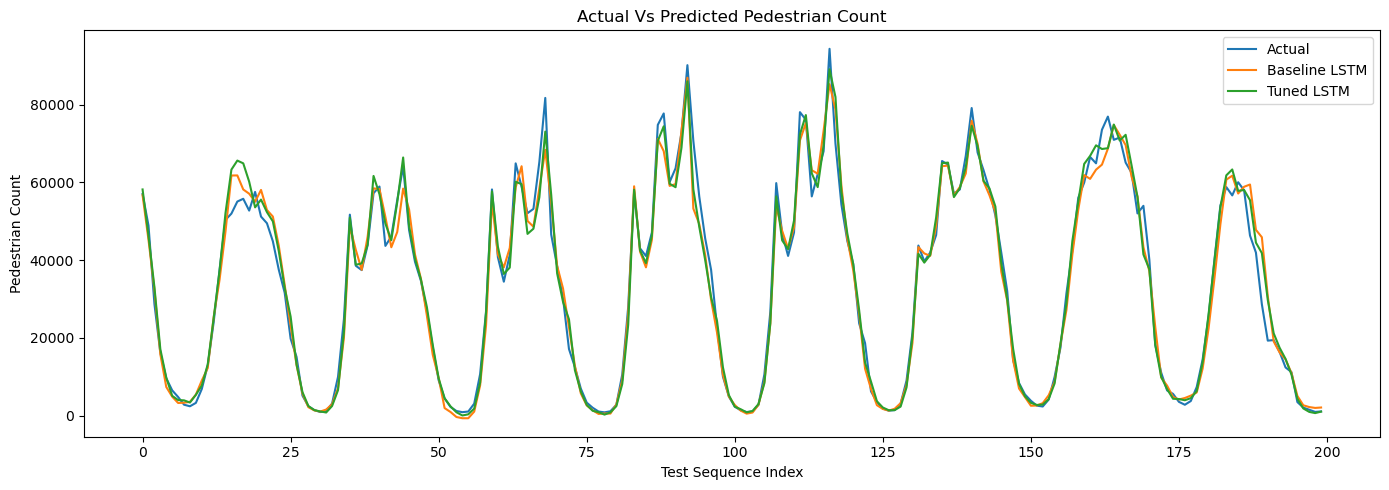

In [109]:
# Set the number of points to plot.
plot_len = 200

# Plot actual and predicted values.
plt.figure(figsize=(14, 5))
plt.plot(
    y_test_actual[:plot_len],
    label="Actual"
)
plt.plot(
    baseline_pred[:plot_len],
    label="Baseline LSTM"
)
plt.plot(
    tuned_pred[:plot_len],
    label="Tuned LSTM"
)
plt.title("Actual Vs Predicted Pedestrian Count")
plt.xlabel("Test Sequence Index")
plt.ylabel("Pedestrian Count")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Using The Best Model

Selecting the best model is necessary because the final prediction should use the model that performed the best during testing. Testing with the best model is an enactment of how the model might perform in the real world, and seeing firsthand how similar the results would be.

### 13.1 Predicting With The Best Model

**Justification**

The best model was the fine-tuned model, so the final prediction will be made with it for the final forecasting step by using the latest available data and predicting the pedestrian count for that time.

**Output Explanation**

The output shows that the Tuned LSTM was selected as the best model, as mentioned earlier.

In [112]:
# Select the best model.
best_model_name = results_df.loc[0, "Model"]

# Store the matching model object.
if best_model_name == "Baseline LSTM":
    best_model = baseline_model
else:
    best_model = tuned_model

# Check the selected model.
print("Best model selected:", best_model_name)

Best model selected: Tuned LSTM


### 13.2 Preparing The Latest Input Window

**Justification**

Preparing the latest input window is necessary because the LSTM model needs a sequence of recent observations before it can make a prediction. Since the model was trained using 24-hour sequences, the latest 24 rows of feature data need to be selected and formatted in the same way. The latest feature window is also scaled using the same scaler from training, which keeps the input format consistent with what the model has already learned.

**Output Explanation**

The output shows that the latest input window was reshaped into 1 sequence, 24 time steps, and 22 features. Ready to be used for prediction.

In [114]:
# Take the latest sequence of feature rows.
latest_X = features_df[feature_cols].tail(SEQ_LEN)

# Scale the latest feature rows.
latest_X_scaled = x_scaler.transform(latest_X)

# Reshape for LSTM input.
latest_X_seq = latest_X_scaled.reshape(
    1,
    SEQ_LEN,
    latest_X_scaled.shape[1]
)

# Check the shape.
print(latest_X_seq.shape)

(1, 24, 22)


### 13.3 Making The Prediction

**Justification**

The model predicts the target in scaled form, so the prediction needs to be converted back to the original pedestrian count scale. This is because the LSTM model was trained using the scaled target variable instead of the original pedestrian count values. The result is also rounded because the pedestrian count should be presented as a whole number, since you can't exactly have half or parts of a person.

**Output Explanation**

The output shows the latest timestamp, the actual pedestrian count, and the predicted pedestrian count. The predicted value is close to the actual value, which suggests that the tuned LSTM model is able to make a reasonable estimate using the most recent 24-hour input sequence.

In [116]:
# Predict the scaled target.
latest_pred_scaled = best_model.predict(
    latest_X_seq,
    verbose=0
).flatten()

# Convert prediction back to original scale.
latest_pred = y_scaler.inverse_transform(
    latest_pred_scaled.reshape(-1, 1)
).flatten()[0]

# Round the predicted pedestrian count.
latest_pred = round(latest_pred)

# Get the latest timestamp and actual value.
latest_time = features_df["datetime_hour"].iloc[-1]
latest_actual = features_df["pedestriancount"].iloc[-1]

# Print the result.
print("Latest timestamp:", latest_time)
print("Actual pedestrian count:", latest_actual)
print("Predicted pedestrian count:", latest_pred)

Latest timestamp: 2026-04-27 03:00:00
Actual pedestrian count: 1097
Predicted pedestrian count: 1018


### 13.4 Bar Chart Of Actual Vs Predicted

**Justification**

A bar chart was included just to have a visual comparison of the tuned LTSM model's prediction against the actual value.

**Output Explanation**

From the chart, the predicted value is slightly lower than the actual value, meaning the model underestimated the pedestrian count for the latest timestamp. However, the two bars are still relatively close, which suggests that the model produced a reasonable prediction.

Though the difference may possibly be due to predictors that were unaccounted for, as pedestrian activity depends on many other factors, like public holidays, WFH policies, and maybe even geopolitical events like the Iran War happening as of 2026.

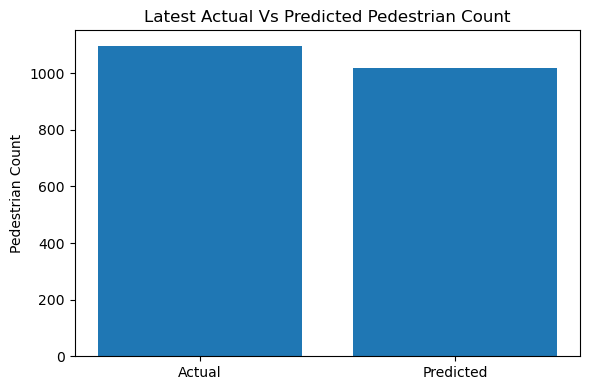

In [118]:
# Plot the latest actual and predicted values.
plt.figure(figsize=(6, 4))
plt.bar(
    ["Actual", "Predicted"],
    [latest_actual, latest_pred]
)
plt.title("Latest Actual Vs Predicted Pedestrian Count")
plt.ylabel("Pedestrian Count")
plt.tight_layout()
plt.show()

## 14. Vancouver References

1. pandas [Internet]. pandas - Python Data Analysis Library. [cited 2026 Mar 19]. Available from: [https://pandas.pydata.org/](https://pandas.pydata.org/)

2. pandas [Internet]. Time series / date functionality — pandas 3.0.2 documentation. [cited 2026 Mar 19]. Available from: [https://pandas.pydata.org/docs/user_guide/timeseries.html](https://pandas.pydata.org/docs/user_guide/timeseries.html)

3. Matplotlib [Internet]. Matplotlib — Visualization with Python. [cited 2026 Mar 19]. Available from: [https://matplotlib.org/](https://matplotlib.org/)

4. scikit-learn [Internet]. 7.3. Preprocessing data — scikit-learn 1.8.0 documentation. [cited 2026 Mar 19]. Available from: [https://scikit-learn.org/stable/modules/preprocessing.html](https://scikit-learn.org/stable/modules/preprocessing.html)

5. TensorFlow [Internet]. Keras: the high-level API for TensorFlow. [cited 2026 Mar 19]. Available from: [https://www.tensorflow.org/guide/keras](https://www.tensorflow.org/guide/keras)

6. Python Software Foundation [Internet]. PEP 8 – Style Guide for Python Code. [cited 2026 Mar 19]. Available from: [https://peps.python.org/pep-0008/](https://peps.python.org/pep-0008/)

7. TensorFlow [Internet]. tf.keras.utils.set_random_seed | TensorFlow v2.16.1. [cited 2026 Mar 19]. Available from: [https://www.tensorflow.org/api_docs/python/tf/keras/utils/set_random_seed](https://www.tensorflow.org/api_docs/python/tf/keras/utils/set_random_seed)

8. Opendatasoft [Internet]. Huwise’s Explore API Reference Documentation. [cited 2026 Mar 19]. Available from: [https://help.opendatasoft.com/apis/ods-explore-v2/](https://help.opendatasoft.com/apis/ods-explore-v2/)

9. City of Melbourne Open Data [Internet]. Pedestrian Counting System - Sensor Locations. [cited 2026 Mar 21]. Available from: [https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-sensor-locations/](https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-sensor-locations/)

10. City of Melbourne Open Data [Internet]. Pedestrian Counting System (counts per hour). [cited 2026 Mar 21]. Available from: [https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-monthly-counts-per-hour/](https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-monthly-counts-per-hour/)

11. City of Melbourne Open Data [Internet]. Microclimate sensors data. [cited 2026 Mar 21]. Available from: [https://data.melbourne.vic.gov.au/explore/dataset/microclimate-sensors-data/](https://data.melbourne.vic.gov.au/explore/dataset/microclimate-sensors-data/)

12. IBM Think [Internet]. What is data profiling? [cited 2026 Mar 24]. Available from: [https://www.ibm.com/think/topics/data-profiling](https://www.ibm.com/think/topics/data-profiling)

13. pandas [Internet]. pandas.DataFrame.shape — pandas 3.0.2 documentation. [cited 2026 Mar 24]. Available from: [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html)

14. pandas [Internet]. pandas.DataFrame.columns — pandas 3.0.2 documentation. [cited 2026 Mar 24]. Available from: [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html)

15. pandas [Internet]. pandas.DataFrame.dtypes — pandas 3.0.2 documentation. [cited 2026 Mar 24]. Available from: [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html)

16. pandas [Internet]. pandas.DataFrame.info — pandas 3.0.2 documentation. [cited 2026 Mar 24]. Available from: [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html)

17. pandas [Internet]. pandas.DataFrame.isna — pandas 3.0.2 documentation. [cited 2026 Mar 24]. Available from: [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html)

18. pandas [Internet]. pandas.DataFrame.describe — pandas 3.0.2 documentation. [cited 2026 Mar 24]. Available from: [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)

19. pandas [Internet]. pandas.to_datetime — pandas 3.0.2 documentation. [cited 2026 Mar 24]. Available from: [https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html)

20. pandas [Internet]. pandas.DataFrame.nunique — pandas 3.0.2 documentation. [cited 2026 Mar 24]. Available from: [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nunique.html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nunique.html)

21. Rogers J, Jonker A. IBM Think [Internet]. What is data cleaning? [cited 2026 Mar 27]. Available from: [https://www.ibm.com/think/topics/data-cleaning](https://www.ibm.com/think/topics/data-cleaning)

22. Tableau [Internet]. Data cleaning: definition, benefits, and how-to. [cited 2026 Mar 27]. Available from: [https://www.tableau.com/learn/articles/what-is-data-cleaning](https://www.tableau.com/learn/articles/what-is-data-cleaning)

23. Applied Machine Learning for Tabular Data [Internet]. 13 Feature Selection. [cited 2026 Mar 31]. Available from: [https://aml4td.org/chapters/feature-selection.html](https://aml4td.org/chapters/feature-selection.html)

24. IBM Think [Internet]. What is feature selection? [cited 2026 Mar 31]. Available from: [https://www.ibm.com/think/topics/feature-selection](https://www.ibm.com/think/topics/feature-selection)

25. Zhou Y, Aryal S, Bouadjenek MR. A comprehensive review of handling missing data: exploring special missing mechanisms. arXiv [Internet]. 2024 Apr 7 [cited 2026 Mar 31]. Available from: [https://arxiv.org/html/2404.04905v1](https://arxiv.org/html/2404.04905v1)

26. Silverberg-Rajna J. Cribl [Internet]. What is data normalization? 2024 Jan 12 [cited 2026 Mar 31]. Available from: [https://cribl.io/glossary/data-normalization/](https://cribl.io/glossary/data-normalization/)

27. The Epidemiologist R Handbook [Internet]. 9 Working with dates. [cited 2026 Mar 31]. Available from: [https://www.epirhandbook.com/en/new_pages/dates.html](https://www.epirhandbook.com/en/new_pages/dates.html)

28. skforecast [Internet]. Time series aggregation - Skforecast Docs. [cited 2026 Mar 31]. Available from: [https://skforecast.org/0.12.1/faq/time-series-aggregation](https://skforecast.org/0.12.1/faq/time-series-aggregation)

29. Microsoft Support [Internet]. Join tables and queries. [cited 2026 Mar 31]. Available from: [https://support.microsoft.com/en-us/office/join-tables-and-queries-3f5838bd-24a0-4832-9bc1-07061a1478f6](https://support.microsoft.com/en-us/office/join-tables-and-queries-3f5838bd-24a0-4832-9bc1-07061a1478f6)

30. IBM Think [Internet]. What is data integration? [cited 2026 Mar 31]. Available from: [https://www.ibm.com/think/topics/data-integration](https://www.ibm.com/think/topics/data-integration)

31. RudderStack [Internet]. What is data validation? Why, when, and how to use it. [cited 2026 Mar 31]. Available from: [https://www.rudderstack.com/learn/data-collection/validation-of-data-collection/](https://www.rudderstack.com/learn/data-collection/validation-of-data-collection/)

32. Google Cloud [Internet]. What is time-series forecasting? [cited 2026 Apr 5]. Available from: [https://cloud.google.com/learn/what-is-time-series](https://cloud.google.com/learn/what-is-time-series)

33. AlSalehy AS, Bailey M. Improving time series data quality: identifying outliers and handling missing values in a multilocation gas and weather dataset. Smart Cities [Internet]. 2025 May 7 [cited 2026 Apr 5];8(3):82. Available from: [https://www.mdpi.com/2624-6511/8/3/82](https://www.mdpi.com/2624-6511/8/3/82)

34. NIST/SEMATECH e-Handbook of Statistical Methods [Internet]. 1.1.1. What is EDA? [cited 2026 Apr 5]. Available from: [https://www.itl.nist.gov/div898/handbook/eda/section1/eda11.htm](https://www.itl.nist.gov/div898/handbook/eda/section1/eda11.htm)

35. Hyndman RJ, Athanasopoulos G. Forecasting: Principles and Practice [Internet]. 2nd ed. 2.3 Time series patterns. [cited 2026 Apr 5]. Available from: [https://otexts.com/fpp2/tspatterns.html](https://otexts.com/fpp2/tspatterns.html)

36. NIST/SEMATECH e-Handbook of Statistical Methods [Internet]. 6.4. Introduction to Time Series Analysis. [cited 2026 Apr 5]. Available from: [https://www.itl.nist.gov/div898/handbook/pmc/section4/pmc4.htm](https://www.itl.nist.gov/div898/handbook/pmc/section4/pmc4.htm)

37. NIST/SEMATECH e-Handbook of Statistical Methods [Internet]. 6.4.4.3. Seasonality. [cited 2026 Apr 5]. Available from: [https://www.itl.nist.gov/div898/handbook/pmc/section4/pmc443.htm](https://www.itl.nist.gov/div898/handbook/pmc/section4/pmc443.htm)

38. NIST/SEMATECH e-Handbook of Statistical Methods [Internet]. 1.3.3.14. Histogram. [cited 2026 Apr 5]. Available from: [https://www.itl.nist.gov/div898/handbook/eda/section3/histogra.htm](https://www.itl.nist.gov/div898/handbook/eda/section3/histogra.htm)

39. PennState Eberly College of Science [Internet]. 3.4.2 - Correlation | STAT 200. [cited 2026 Apr 5]. Available from: [https://online.stat.psu.edu/stat200/lesson/3/3.4/3.4.2](https://online.stat.psu.edu/stat200/lesson/3/3.4/3.4.2)

40. Frost J. Statistics By Jim [Internet]. Using moving averages to smooth time series data. [cited 2026 Apr 9]. Available from: [https://statisticsbyjim.com/time-series/moving-averages-smoothing/](https://statisticsbyjim.com/time-series/moving-averages-smoothing/)

41. DataCamp [Internet]. Time series decomposition: trends, seasonality, and noise. [cited 2026 Apr 9]. Available from: [https://www.datacamp.com/tutorial/time-series-decomposition](https://www.datacamp.com/tutorial/time-series-decomposition)

42. PennState Eberly College of Science [Internet]. 10.2 - Autocorrelation and Time Series Methods | STAT 462. [cited 2026 Apr 9]. Available from: [https://online.stat.psu.edu/stat462/node/188/](https://online.stat.psu.edu/stat462/node/188/)

43. Minitab Support [Internet]. Interpret all statistics and graphs for Augmented Dickey-Fuller Test. [cited 2026 Apr 9]. Available from: [https://support.minitab.com/en-us/minitab/help-and-how-to/statistical-modeling/time-series/how-to/augmented-dickey-fuller-test/interpret-the-results/all-statistics-and-graphs/](https://support.minitab.com/en-us/minitab/help-and-how-to/statistical-modeling/time-series/how-to/augmented-dickey-fuller-test/interpret-the-results/all-statistics-and-graphs/)

44. IBM Think [Internet]. What is a feature engineering? [cited 2026 Apr 13]. Available from: [https://www.ibm.com/think/topics/feature-engineering](https://www.ibm.com/think/topics/feature-engineering)

45. Gordon J. dotData [Internet]. Practical guide for feature engineering of time series data. 2023 Jun 20 [cited 2026 Apr 13]. Available from: [https://dotdata.com/blog/practical-guide-for-feature-engineering-of-time-series-data/](https://dotdata.com/blog/practical-guide-for-feature-engineering-of-time-series-data/)

46. skforecast [Internet]. Cyclical features in time series - Skforecast Docs. [cited 2026 Apr 13]. Available from: [https://skforecast.org/latest/faq/cyclical-features-time-series.html](https://skforecast.org/latest/faq/cyclical-features-time-series.html)

47. Feature-engine [Internet]. Forecasting Features — 1.8.3. [cited 2026 Apr 13]. Available from: [https://feature-engine.trainindata.com/en/1.8.x/user_guide/timeseries/forecasting/index.html](https://feature-engine.trainindata.com/en/1.8.x/user_guide/timeseries/forecasting/index.html)

48. Feature-engine [Internet]. LagFeatures — 1.8.3. [cited 2026 Apr 13]. Available from: [https://feature-engine.trainindata.com/en/1.8.x/user_guide/timeseries/forecasting/LagFeatures.html](https://feature-engine.trainindata.com/en/1.8.x/user_guide/timeseries/forecasting/LagFeatures.html)

49. APXML [Internet]. Train-Test Split Strategies for Time Series Data. [cited 2026 Apr 17]. Available from: [https://apxml.com/courses/time-series-analysis-forecasting/chapter-6-model-evaluation-selection/train-test-split-time-series](https://apxml.com/courses/time-series-analysis-forecasting/chapter-6-model-evaluation-selection/train-test-split-time-series)

50. V7 Labs [Internet]. Train Test Validation Split: how to and best practices. 2024 [cited 2026 Apr 17]. Available from: [https://www.v7labs.com/blog/train-validation-test-set](https://www.v7labs.com/blog/train-validation-test-set)

51. Belcic I, Stryker C. IBM Think [Internet]. What is supervised learning? [cited 2026 Apr 17]. Available from: [https://www.ibm.com/think/topics/supervised-learning](https://www.ibm.com/think/topics/supervised-learning)

52. APXML [Internet]. Feature Scaling: Normalization and Standardization. [cited 2026 Apr 17]. Available from: [https://apxml.com/courses/introduction-to-neural-networks/chapter-2-data-preparation-neural-networks/feature-scaling](https://apxml.com/courses/introduction-to-neural-networks/chapter-2-data-preparation-neural-networks/feature-scaling)

53. Brownlee J. Machine Learning Mastery [Internet]. Time series prediction with LSTM recurrent neural networks in Python with Keras. 2022 Aug 7 [cited 2026 Apr 22]. Available from: [https://machinelearningmastery.com/time-series-prediction-lstm-recurrent-neural-networks-python-keras/](https://machinelearningmastery.com/time-series-prediction-lstm-recurrent-neural-networks-python-keras/)

54. Li D, Hasanaj E, Li S. Machine Learning Blog | ML@CMU | Carnegie Mellon University [Internet]. 3 – Baselines. 2020 Aug 31 [cited 2026 Apr 22]. Available from: [https://blog.ml.cmu.edu/2020/08/31/3-baselines/](https://blog.ml.cmu.edu/2020/08/31/3-baselines/)

55. TensorFlow [Internet]. Time series forecasting | TensorFlow Core. [cited 2026 Apr 22]. Available from: [https://www.tensorflow.org/tutorials/structured_data/time_series](https://www.tensorflow.org/tutorials/structured_data/time_series)

56. Keras [Internet]. Adam. [cited 2026 Apr 22]. Available from: [https://keras.io/api/optimizers/adam/](https://keras.io/api/optimizers/adam/)

57. APXML [Internet]. Regression Loss Functions (MSE, MAE). [cited 2026 Apr 22]. Available from: [https://apxml.com/courses/introduction-to-deep-learning/chapter-3-training-loss-optimization/regression-loss-functions](https://apxml.com/courses/introduction-to-deep-learning/chapter-3-training-loss-optimization/regression-loss-functions)

58. Das SR. Deep Learning [Internet]. Improving Model Generalization. [cited 2026 Apr 22]. Available from: [https://srdas.github.io/DLBook/ImprovingModelGeneralization.html](https://srdas.github.io/DLBook/ImprovingModelGeneralization.html)

59. Google for Developers [Internet]. Overfitting: interpreting loss curves. [cited 2026 Apr 22]. Available from: [https://developers.google.com/machine-learning/crash-course/overfitting/interpreting-loss-curves](https://developers.google.com/machine-learning/crash-course/overfitting/interpreting-loss-curves)

60. Amazon Web Services [Internet]. What is Hyperparameter Tuning? - Hyperparameter Tuning Methods Explained. [cited 2026 Apr 25]. Available from: [https://aws.amazon.com/what-is/hyperparameter-tuning/](https://aws.amazon.com/what-is/hyperparameter-tuning/)

61. Srivastava N, Hinton G, Krizhevsky A, Sutskever I, Salakhutdinov R. Dropout: a simple way to prevent neural networks from overfitting. J Mach Learn Res [Internet]. 2014 [cited 2026 Apr 25];15(56):1929-58. Available from: [https://jmlr.org/papers/v15/srivastava14a.html](https://jmlr.org/papers/v15/srivastava14a.html)

62. Belcic I, Stryker C. IBM Think [Internet]. What is learning rate in machine learning? [cited 2026 Apr 25]. Available from: [https://www.ibm.com/think/topics/learning-rate](https://www.ibm.com/think/topics/learning-rate)

63. Brownlee J. Machine Learning Mastery [Internet]. How to control the stability of training neural networks with the batch size. [cited 2026 Apr 25]. Available from: [https://machinelearningmastery.com/how-to-control-the-speed-and-stability-of-training-neural-networks-with-gradient-descent-batch-size/](https://machinelearningmastery.com/how-to-control-the-speed-and-stability-of-training-neural-networks-with-gradient-descent-batch-size/)

64. DataCamp [Internet]. RMSE explained: a guide to regression prediction accuracy. [cited 2026 Apr 28]. Available from: [https://www.datacamp.com/tutorial/rmse](https://www.datacamp.com/tutorial/rmse)

65. APXML [Internet]. Regression Evaluation Metrics (MAE, MSE, R2). [cited 2026 Apr 28]. Available from: [https://apxml.com/courses/getting-started-with-scikit-learn/chapter-2-supervised-learning-regression/regression-evaluation-metrics](https://apxml.com/courses/getting-started-with-scikit-learn/chapter-2-supervised-learning-regression/regression-evaluation-metrics)

66. DataCamp [Internet]. Mean Absolute Error explained: measuring model accuracy. 2025 Aug 8 [cited 2026 Apr 28]. Available from: [https://www.datacamp.com/tutorial/mean-absolute-error](https://www.datacamp.com/tutorial/mean-absolute-error)

67. DataCamp [Internet]. R-squared explained: measuring model fit. [cited 2026 Apr 28]. Available from: [https://www.datacamp.com/tutorial/r-squared](https://www.datacamp.com/tutorial/r-squared)

68. MathWorks [Internet]. Visualize and assess model performance in Regression Learner. [cited 2026 Apr 28]. Available from: [https://www.mathworks.com/help/stats/assess-model-performance-in-regression-learner.html](https://www.mathworks.com/help/stats/assess-model-performance-in-regression-learner.html)

69. Piñeiro G, Perelman S, Guerschman JP, Paruelo JM. How to evaluate models: observed vs. predicted or predicted vs. observed? Ecol Modell [Internet]. 2008 Sep 10 [cited 2026 Apr 28];216(3-4):316-22. Available from: [https://www.sciencedirect.com/science/article/abs/pii/S0304380008002305](https://www.sciencedirect.com/science/article/abs/pii/S0304380008002305)